## Imports and set data path

In [1]:
# Imports
import sys
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from scipy.stats import gaussian_kde
import math
import rounders
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Set options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)
alt.data_transformers.disable_max_rows()


# Set data path here
data_path = 'data/airfoil_9k_data.h5'
data_path_small = 'data/airfoil_01k_data_rng.h5'


In [2]:
# %pip install altair
# %pip install rounders

## Explore contents and architecture of .h5 data file

`Data Structure` <br>
The .h5 data file is structured as follows: <br>

|-- root (group, 3 members) <br>
 &emsp;&emsp;	|-- shape (group, 4 members) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- landmarks (dataset, shape(8996, 1001, 2)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- grassmann (dataset, shape(8996, 4)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- cst (dataset, shape(8996, 19)) <br>
 &emsp;&emsp;	&emsp;&emsp;	|-- bezier (dataset, shape(8996, 15)) <br>
 &emsp;&emsp;	|-- alpha+04 (group, 3 members) <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_d (dataset, shape(8996,)) : coefficient of drag <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_l (dataset, shape(8996,)) : coefficient of lift <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_m (dataset, shape(8996,)) : moment coefficient <br>
 &emsp;&emsp;  	 &emsp;&emsp;	|-- flow_field (group, 8996 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	|-- XXXX (group, 7 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- x (dataset, shape(n_mesh,)) : x location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- y (dataset, shape(n_mesh,)) : y location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho (dataset, shape(n_mesh,)) : density <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_u (dataset, shape(n_mesh,)) : momentum in x-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_v (dataset, shape(n_mesh,)) : momentum in y-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- e (dataset, shape(n_mesh,)) : total energy <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- omega (dataset, shape(n_mesh,)) : vorticity <br>
 &emsp;&emsp;	|-- alpha+12 (group, 3 members) <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_d (dataset, shape(8996,)) : coefficient of drag <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_l (dataset, shape(8996,)) : coefficient of lift <br>
 &emsp;&emsp;	 &emsp;&emsp;	|-- C_m (dataset, shape(8996,)) : moment coefficient <br>
 &emsp;&emsp;  	 &emsp;&emsp;	|-- flow_field (group, 8996 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	|-- XXXX (group, 7 members) <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- x (dataset, shape(n_mesh,)) : x location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- y (dataset, shape(n_mesh,)) : y location <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho (dataset, shape(n_mesh,)) : density <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_u (dataset, shape(n_mesh,)) : momentum in x-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- rho_v (dataset, shape(n_mesh,)) : momentum in y-direction <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- e (dataset, shape(n_mesh,)) : total energy <br>
 &emsp;&emsp;  	 &emsp;&emsp;	&emsp;&emsp;	&emsp;&emsp;	|-- omega (dataset, shape(n_mesh,)) : vorticity <br>


** The flow fields for the 8,996 airfoils are indexed by zero-padded group names 'XXXX' from 0000 to 8995. The number of mesh points for each airfoil flow field is different and is determined by the airfoil's shape.

In [3]:
# Open file and print the top level group names/keys
# This data set contains 8996 unique airfoil shapes
# The alpha+XX groups represents the airfoil angle of attack (4 and 12 degrees) and contain datasets for the coeffients of drag, lift, and moment
# The shape group contains 4 datasets representing the different parameterizations of the airfoil geometries.
with h5py.File(data_path, 'r') as hf:
    top_groups = [k for k in hf.keys()]
    print(top_groups)


['alpha+04', 'alpha+12', 'shape']


In [4]:
# Explore contents of the three top level groups

# Each alpha+XX group contains 3 datasets and 1 group:
#   C_d: dataset, (8996,) array representing the coeffients of drag for each airfoil geometry at the specified angle of attack
#   C_l: dataset, (8996,) array representing the coeffients of lift for each airfoil geometry at the specified angle of attack
#   C_m: dataset, (8996,) array representing the coeffients of moment for each airfoil geometry at the specified angle of attack
#   flow_field: group containing 8996 subgroups associated with each airfoil and containing 7 datasets:
#      x: (n_mesh,) array representing the x locations of the mesh points
#      y: (n_mesh,) array representing the y locations of the mesh points
#      rho: (n_mesh,) array representing the flow density at each mesh point
#      rho_u: (n_mesh,) array representing the flow momentum in the x-direction at each mesh point
#      rho_v: (n_mesh,) array representing the flow momentum in the y-direction at each mesh point
#      e: (n_mesh,) array representing the total energy in the flow at each mesh point
#      omega: (n_mesh,) array representing the flow vorticity at each mesh point
#   Note that the number of mesh point n_mesh can be different for each airfoil
# The shape group contains 4 members representing different paramerizations of the airfoil geometry:
#   landmarks:  dataset (8996, 1001, 2) array representing the geometries of each airfoil via (x, y) landmarks.
#   grassmann:  dataset (8996, 4) array representing the geometries of each airfoil via Grassmann representations.
#   cst:        dataset (8996, 19) array representing the geometries of each airfoil via Class-Shape transformations.
#   bezier:     dataset (8996, 15) array representing the goemetries of each airfoil via Bezier curves.

with h5py.File(data_path, 'r') as hf:
    for name in top_groups:
        print('-------------------------------------------------')
        print('Group Name:', name)
        print('Group Info:', hf[name])
        print('')
        
        if 'alpha' in name:
            print('Aerodynamic quantities:')
            for key in hf[name].keys():
                if 'flow' in key:
                    for i in range(3):
                        print('Flow Field data for airfoil {:04d}'.format(i))
                        for flow_key in hf[name][key]['{:04d}'.format(i)].keys():
                            print('  ', hf[name][key]['{:04d}'.format(i)][flow_key])    
                else:
                    print(hf[name][key])
        else:
            print('Airfoil shape data:')
            for key in hf[name].keys():
                print(hf[name][key])
    print('-------------------------------------------------')
    

-------------------------------------------------
Group Name: alpha+04
Group Info: <HDF5 group "/alpha+04" (4 members)>

Aerodynamic quantities:
<HDF5 dataset "C_d": shape (8996,), type "<f8">
<HDF5 dataset "C_l": shape (8996,), type "<f8">
<HDF5 dataset "C_m": shape (8996,), type "<f8">
Flow Field data for airfoil 0000
   <HDF5 dataset "e": shape (55082,), type "<f8">
   <HDF5 dataset "omega": shape (55082,), type "<f8">
   <HDF5 dataset "rho": shape (55082,), type "<f8">
   <HDF5 dataset "rho_u": shape (55082,), type "<f8">
   <HDF5 dataset "rho_v": shape (55082,), type "<f8">
   <HDF5 dataset "x": shape (55082,), type "<f8">
   <HDF5 dataset "y": shape (55082,), type "<f8">
Flow Field data for airfoil 0001
   <HDF5 dataset "e": shape (56422,), type "<f8">
   <HDF5 dataset "omega": shape (56422,), type "<f8">
   <HDF5 dataset "rho": shape (56422,), type "<f8">
   <HDF5 dataset "rho_u": shape (56422,), type "<f8">
   <HDF5 dataset "rho_v": shape (56422,), type "<f8">
   <HDF5 dataset 

# Downsizing the .h Data Source

**Downsizes 50gb airfoild dataset to 6gb**  
Just gets the first 1000 rows of the stored data

In [5]:
# # n = 1000  # number of samples to keep

# # with h5py.File('airfoil_9k_data.h5', 'r') as src, \
# #      h5py.File('airfoil_1k_data.h5', 'w') as dst:
# #     for group in src.keys():
# #         for dataset in src[group].keys():
# #             data = src[group][dataset][:n]
# #             dst.require_group(group).create_dataset(dataset, data=data)

# # print('Done')

# n = 1000  # number of samples to keep

# src_path = 'data/airfoil_9k_data.h5'
# dst_path = 'data/airfoil_1k_data.h5'

# with h5py.File(src_path, 'r') as src, h5py.File(dst_path, 'w') as dst:
#     # Copy shape datasets (slice first n rows)
#     for ds_name in src['shape'].keys():
#         dst.require_group('shape').create_dataset(ds_name, data=src['shape'][ds_name][:n])

#     for alpha in ['alpha+04', 'alpha+12']:
#         # Copy scalar aerodynamic coefficients
#         for coeff in ['C_d', 'C_l', 'C_m']:
#             dst.require_group(alpha).create_dataset(coeff, data=src[alpha][coeff][:n])

#         # Copy first n flow fields (each is a subgroup, not a dataset)
#         ff_dst = dst[alpha].require_group('flow_field')
#         for key in sorted(src[alpha]['flow_field'].keys())[:n]:
#             dst_ff = ff_dst.require_group(key)
#             for field in src[alpha]['flow_field'][key].keys():
#                 dst_ff.create_dataset(field, data=src[alpha]['flow_field'][key][field][()])

# print('Done')

**Downsizes 50gb airfoild dataset to ~1gb**  
Random selection of data through Systematic Sampling to evenly get data across the file.  
Warning: Long Run

In [6]:
# import numpy as np
# import h5py

# n = 100
# total = 8996
# step = total // n  # every ~9th sample
# rng = np.random.default_rng(seed=42)
# offset = rng.integers(0, step)
# indices = np.arange(offset, total, step)[:n]

# src_path = 'data/airfoil_9k_data.h5'
# dst_path = 'data/airfoil_01k_data_rng.h5'

# with h5py.File(src_path, 'r') as src, h5py.File(dst_path, 'w') as dst:
#     for ds_name in src['shape'].keys():
#         dst.require_group('shape').create_dataset(ds_name, data=src['shape'][ds_name][indices])

#     for alpha in ['alpha+04', 'alpha+12']:
#         for coeff in ['C_d', 'C_l', 'C_m']:
#             dst.require_group(alpha).create_dataset(coeff, data=src[alpha][coeff][indices])

#         ff_dst = dst[alpha].require_group('flow_field')
#         for new_idx, old_idx in enumerate(indices):
#             key = '{:04d}'.format(old_idx)
#             dst_ff = ff_dst.require_group('{:04d}'.format(new_idx))
#             for field in src[alpha]['flow_field'][key].keys():
#                 dst_ff.create_dataset(field, data=src[alpha]['flow_field'][key][field][()])

# print('Done')


Viewing Folders Inside the h5 file

In [7]:
# with h5py.File(data_path, 'r') as hf:
#     hf.visit(lambda name: print(name) if isinstance(hf[name], h5py.Group) else None)

# Working with Downsized Dataset Information

### Visualizing Downsized Results

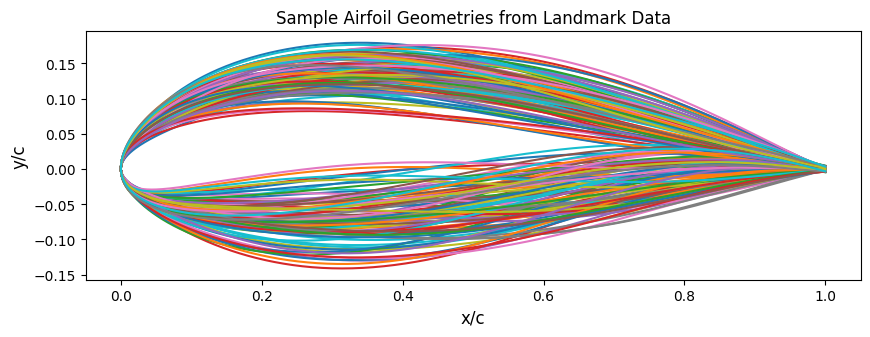

In [8]:
# clears current figure
# Visualize the first 5 airfoil geometries using the landmarks dataset
plt.figure(figsize=(10, 6))
with h5py.File(data_path_small, 'r') as hf:
    landmarks = hf['shape']['landmarks'][()]
    af_shape_count = 0
    for landmark in landmarks:
        plt.plot(landmark[:, 0], landmark[:, 1], label='airfoil {}'.format(af_shape_count))
        af_shape_count += 1
plt.xlabel('x/c', fontsize=12)
plt.ylabel('y/c', fontsize=12)
plt.gca().set_aspect(1.)
# plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
plt.title('Sample Airfoil Geometries from Landmark Data')
plt.show()

Loading Functions from Utility

In [9]:
import importlib
import airfoil_utils
importlib.reload(airfoil_utils)
from airfoil_utils import (
    load_shape, load_aero_coeffs, load_flow_field,
    compute_thickness_camber, thickness_camber_dataframes,
    pca_reduce, pca_variance_curve,
    plot_airfoil_geometries, plot_pairwise_distributions,
    plot_aero_violins, plot_aero_vs_geometry, plot_flow_field, 
    plot_flow_field_plotly
)

Loading Data

In [10]:
# Load data
landmarks = load_shape(data_path_small, 'landmarks') # main parameter to use
# grassmann = load_shape(data_path_small, 'grassmann')
# cst       = load_shape(data_path_small, 'cst')
# bezier    = load_shape(data_path_small, 'bezier')

# Aerodynamic Coefficients
cl04, cd04, cm04 = load_aero_coeffs(data_path_small, 'alpha+04') # Angle of Attack 4 deg
cl12, cd12, cm12 = load_aero_coeffs(data_path_small, 'alpha+12') # Angle of Attack 12 deg

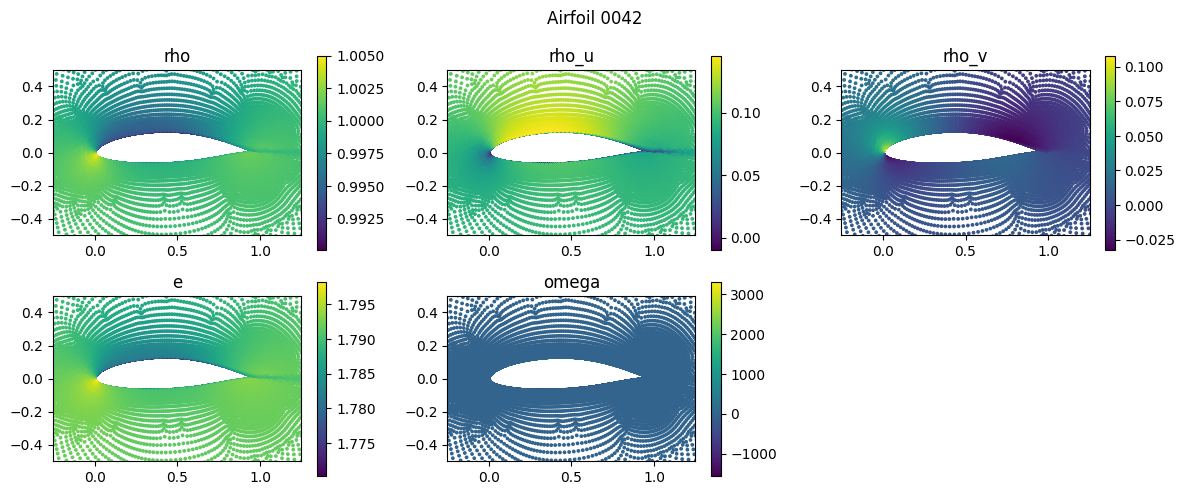

In [11]:
# Flow field
ff = load_flow_field(data_path_small, idx=42)
plot_flow_field(ff, idx=42)
# plot_flow_field_plotly(ff, idx=42, metric='rho')

Visualizing Flow Field of Two Angles of Attack of the same Airfoil

In [12]:
ff_04 = load_flow_field(data_path_small, idx=42, alpha='alpha+04')
ff_12 = load_flow_field(data_path_small, idx=42, alpha='alpha+12')

print("Angle of Attack 4 deg")
plot_flow_field_plotly(ff_04, idx=42, metric='rho')
print("Angle of Attack 12 deg")
plot_flow_field_plotly(ff_12, idx=42, metric='rho')


Angle of Attack 4 deg


Angle of Attack 12 deg


Loading Coefficent Results after Downsizing

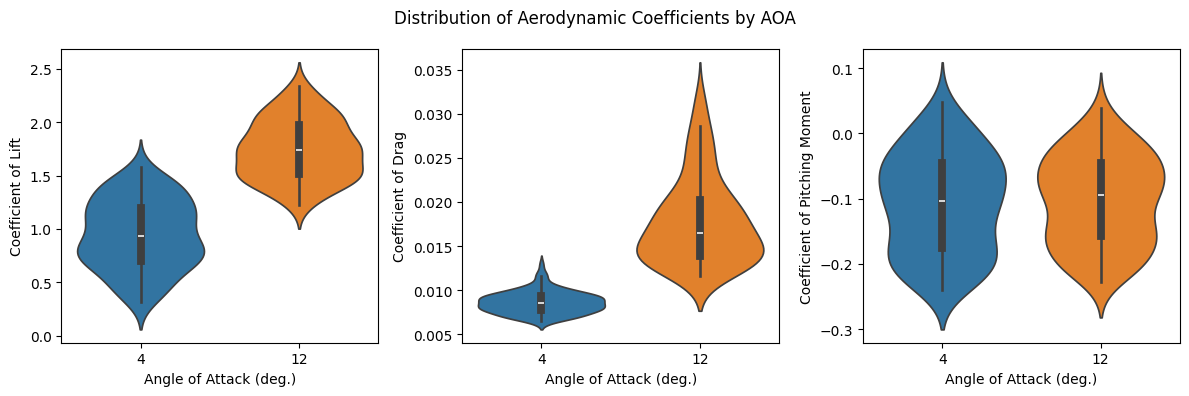

In [13]:
plot_aero_violins(cl04, cd04, cm04, cl12, cd12, cm12)

Rounding Coefficients to simplify prediction complexity

Unique values BEFORE rounding:
  cl04: 100  |  cd04: 100  |  cm04: 100
  cl12: 100  |  cd12: 100  |  cm12: 100


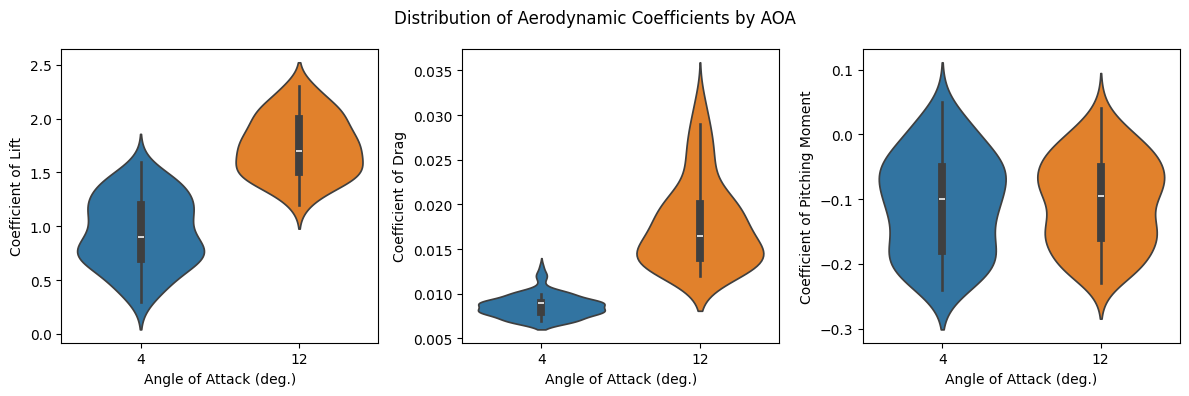

Unique values AFTER rounding:
  cl04: 14  |  cd04: 7  |  cm04: 29
  cl12: 12  |  cd12: 21  |  cm12: 27


In [14]:
# Before rounding
print("Unique values BEFORE rounding:")
print(f"  cl04: {len(np.unique(cl04))}  |  cd04: {len(np.unique(cd04))}  |  cm04: {len(np.unique(cm04))}")
print(f"  cl12: {len(np.unique(cl12))}  |  cd12: {len(np.unique(cd12))}  |  cm12: {len(np.unique(cm12))}")

plot_aero_violins(
    cl04.round(1), cd04.round(3), cm04.round(2),
    cl12.round(1), cd12.round(3), cm12.round(2)
)

cl04_round = cl04.round(1)
cd04_round = cd04.round(3)
cm04_round = cm04.round(2)
cl12_round = cl12.round(1)
cd12_round = cd12.round(3)
cm12_round = cm12.round(2)

# After rounding
print("Unique values AFTER rounding:")
print(f"  cl04: {len(np.unique(cl04_round))}  |  cd04: {len(np.unique(cd04_round))}  |  cm04: {len(np.unique(cm04_round))}")
print(f"  cl12: {len(np.unique(cl12_round))}  |  cd12: {len(np.unique(cd12_round))}  |  cm12: {len(np.unique(cm12_round))}")


### Data Processing Work

Converting Results into Grid Images  
Landmark data x,y are not the same for each airfoil and may hurt CNN learning. Adjusting them throug interpolation into fixed Grids should help fix the issue

In [15]:
importlib.reload(airfoil_utils)
from airfoil_utils import landmarks_to_grid, plot_airfoil_grid


In [16]:

landmarks = load_shape(data_path_small, 'landmarks')
# grids = landmarks_to_grid(landmarks, resolution=128)  # shape: (N, 128, 128)
# save
grids = landmarks_to_grid(landmarks, resolution=128, padding=0.2, save_path='data/airfoil_01k_grid_128.h5')

# with h5py.File('data/grids_128.h5', 'r') as hf:
#     alpha4_grids = hf['alpha4'][()]

Saved 100 airfoils × 3 AOAs to data/airfoil_01k_grid_128.h5


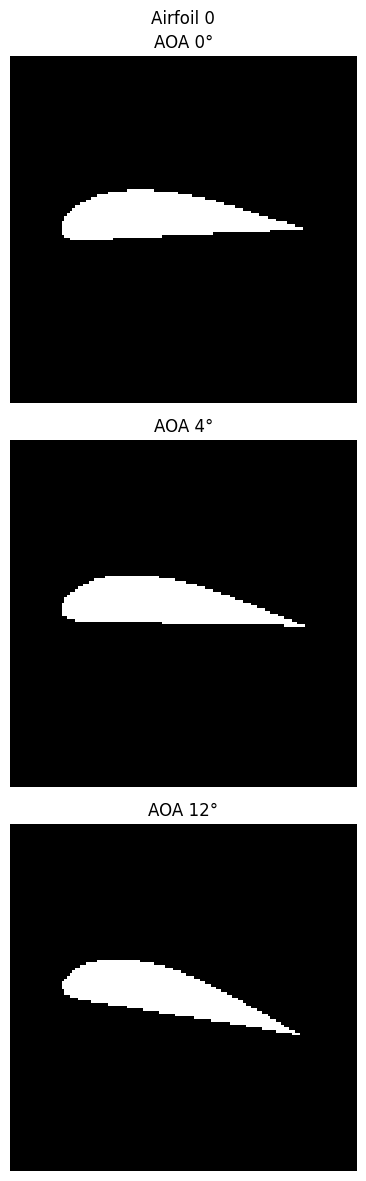

In [17]:
import math
importlib.reload(airfoil_utils)
# grids = landmarks_to_grid(landmarks)
plot_airfoil_grid(grids, idx=0)


Angle Dimensions for 4deg angle of attack and 12deg angle of attack

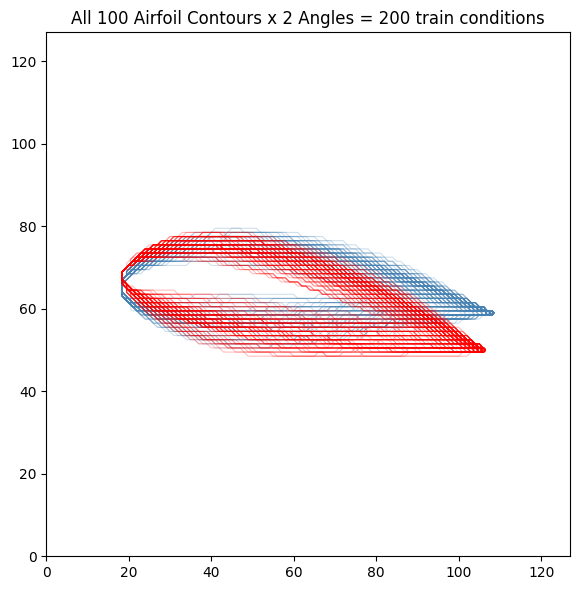

In [18]:
orientation = 'alpha4'  # choose: 'alpha0', 'alpha4', 'alpha12'

with h5py.File('data/airfoil_01k_grid_128.h5', 'r') as hf:
    grids = hf[orientation][()]  # (100, 128, 128)

plt.figure(figsize=(10, 6))
for grid in grids:
    plt.contour(grid, levels=[0.5], colors=['steelblue'], alpha=0.25, linewidths=0.8)


orientation = 'alpha12'  # choose: 'alpha0', 'alpha4', 'alpha12'

with h5py.File('data/airfoil_01k_grid_128.h5', 'r') as hf:
    grids = hf[orientation][()]  # (100, 128, 128)

for grid in grids:
    plt.contour(grid, levels=[0.5], colors=['red'], alpha=0.25, linewidths=0.8)

plt.gca().set_aspect(1.)
plt.title(f'All 100 Airfoil Contours x 2 Angles = 200 train conditions')
plt.tight_layout()
plt.show()

## CNN Modeling

Combining and Assigning Aerodynamic Coefficient Values to their corresponding Airfoil designs

In [19]:
def build_dataset(h5_path, cl04, cd04, cm04, cl12, cd12, cm12):
    with h5py.File(h5_path, 'r') as hf:
        grids_04 = hf['alpha4'][()]   # (100, 128, 128)
        grids_12 = hf['alpha12'][()]  # (100, 128, 128)

    x_data = np.concatenate([grids_04, grids_12], axis=0)  # (200, 128, 128)

    y_04 = np.stack([cl04, cd04, cm04], axis=1)  # (100, 3)
    y_12 = np.stack([cl12, cd12, cm12], axis=1)  # (100, 3)
    y_data = np.concatenate([y_04, y_12], axis=0)  # (200, 3)

    return x_data, y_data


x_data, y_data = build_dataset(
    'data/airfoil_01k_grid_128.h5',
    cl04_round, cd04_round, cm04_round,
    cl12_round, cd12_round, cm12_round
)

print("x_data:", x_data.shape)  # (200, 128, 128)
print("y_data:", y_data.shape)  # (200, 3) — [cl, cd, cm]


x_data: (200, 128, 128)
y_data: (200, 3)


Splitting Data to Get Train/Validation Data and Test Data

In [20]:
from sklearn.model_selection import train_test_split


# --- Step 1: Split into Train (70%) and Temp (30%) ---
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x_data, y_data,
    test_size=0.1,           # 30% for val+test
    random_state=42,         # reproducibility
    stratify=None            # set to y if classification
)

print(f"Train and Val size: {len(x_train_val)} rows ({len(x_train_val)/len(x_data)*100:.1f}%)")
print(f"Test size: {len(x_test)} rows ({len(x_test)/len(x_data)*100:.1f}%)")

Train and Val size: 180 rows (90.0%)
Test size: 20 rows (10.0%)


In [31]:
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# --- Preprocess inputs: add channel dim, cast to float ---
x_train_val    = x_train_val.reshape(-1, 128, 128, 1).astype("float32")
x_test     = x_test.reshape(-1, 128, 128, 1).astype("float32")

# y_data is already float (cl, cd, cm) — no one-hot encoding needed

# --- CNN Regression Model (3 outputs: cl, cd, cm) ---
model = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3)  # regression: cl, cd, cm. activation="softmax" is only for classification
])

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
model.summary()

history = model.fit(
    x_train_val, y_train_val,
    epochs=20,
    batch_size=16, #Common rule of thumb: 16,32, or 64 batch size should be roughly sqrt(sample size).
    # validation_data=(x_val, y_val)
    validation_split=0.1
)

model.save("models/airfoil_cnn.keras")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,267,267 (12.46 MB)

 Trainable params: 3,267,267 (12.46 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.1689 - mae: 0.2705 - val_loss: 0.0918 - val_mae: 0.1898
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0776 - mae: 0.1961 - val_loss: 0.0192 - val_mae: 0.1090
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0687 - mae: 0.1835 - val_loss: 0.0433 - val_mae: 0.1290
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0654 - mae: 0.1761 - val_loss: 0.0160 - val_mae: 0.0832
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0602 - mae: 0.1701 - val_loss: 0.0054 - val_mae: 0.0518
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0583 - mae: 0.1609 - val_loss: 0.0336 - val_mae: 0.1093
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0639 - mae: 0.1695 - val_loss: 0.0423 - val_mae: 0.1266
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0514 - mae: 0.1520 - val_loss: 0.0030 - val_mae: 0.0349
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.042

### Hyperparameter Tuning with Keras Tuner

In [33]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import os

def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(128, 128, 1)))  # airfoil grid size

    # Block 1
    model.add(layers.Conv2D(
        filters=hp.Choice("filters_1", [16, 32, 48]),
        kernel_size=hp.Choice("kernel_1", [3, 5]),
        activation="relu",
        padding="same"
    ))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(
        filters=hp.Choice("filters_2", [32, 64, 96]),
        kernel_size=hp.Choice("kernel_2", [3, 5]),
        activation="relu",
        padding="same"
    ))
    model.add(layers.MaxPooling2D((2, 2)))

    # Optional block 3
    if hp.Boolean("use_block3"):
        model.add(layers.Conv2D(
            filters=hp.Choice("filters_3", [64, 96, 128]),
            kernel_size=3,
            activation="relu",
            padding="same"
        ))

    model.add(layers.Flatten())
    model.add(layers.Dense(
        units=hp.Choice("dense_units", [64, 128, 256]),
        activation="relu"
    ))
    model.add(layers.Dropout(hp.Float("dropout", 0.2, 0.6, step=0.1)))
    model.add(layers.Dense(3))  # regression: cl, cd, cm — no activation

    opt_name = hp.Choice("optimizer", ["adam", "rmsprop"])
    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 5e-4, 1e-4])

    optimizer = (keras.optimizers.Adam(learning_rate=lr)
                 if opt_name == "adam"
                 else keras.optimizers.RMSprop(learning_rate=lr))

    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
    return model

tuner = kt.Hyperband(
    build_model,
    objective="val_mae",       # regression metric
    max_epochs=12,
    factor=3,
    directory="kt_results",
    project_name="airfoil_cnn",
    overwrite=True
)

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

tuner.search(
    x_train_val, y_train_val,
    validation_split=0.1,
    epochs=12,
    batch_size=16,             # smaller — only ~180 training samples
    callbacks=[early_stop],
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k in best_hp.values:
    print(f"  {k}: {best_hp.get(k)}")

best_model = tuner.get_best_models(1)[0]
test_loss, test_mae = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Best model — test MSE: {test_loss:.4f}  test MAE: {test_mae:.4f}")

os.makedirs("models", exist_ok=True)
best_model.save("models/airfoil_cnn_tuned.keras")
print("Saved: models/airfoil_cnn_tuned.keras")


Trial 30 Complete [00h 00m 09s]
val_mae: 0.055001359432935715

Best val_mae So Far: 0.03710018843412399
Total elapsed time: 00h 01m 56s
Best hyperparameters:
  filters_1: 32
  kernel_1: 5
  filters_2: 64
  kernel_2: 3
  use_block3: False
  dense_units: 64
  dropout: 0.2
  optimizer: adam
  learning_rate: 0.0005
  filters_3: 128
  tuner/epochs: 12
  tuner/initial_epoch: 4
  tuner/bracket: 2
  tuner/round: 2
  tuner/trial_id: 0012
Best model — test MSE: 0.0035  test MAE: 0.0417
Saved: models/airfoil_cnn_tuned.keras


### Model Evaluation of CNN

Test MSE: 0.0107
Test MAE: 0.0667

Per-output metrics:
  cl: MAE=0.1635  RMSE=0.1770  R²=0.8598
  cd: MAE=0.0153  RMSE=0.0177  R²=-7.9202
  cm: MAE=0.0214  RMSE=0.0242  R²=0.8847


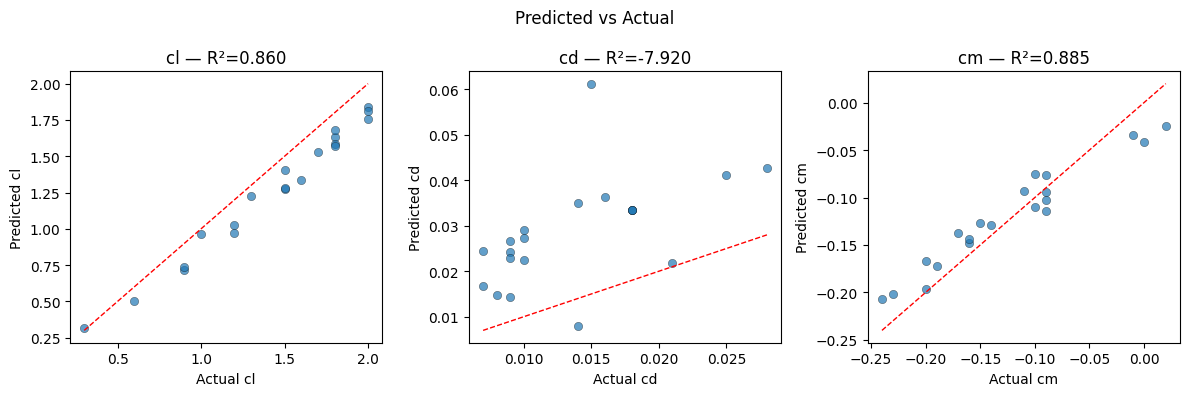

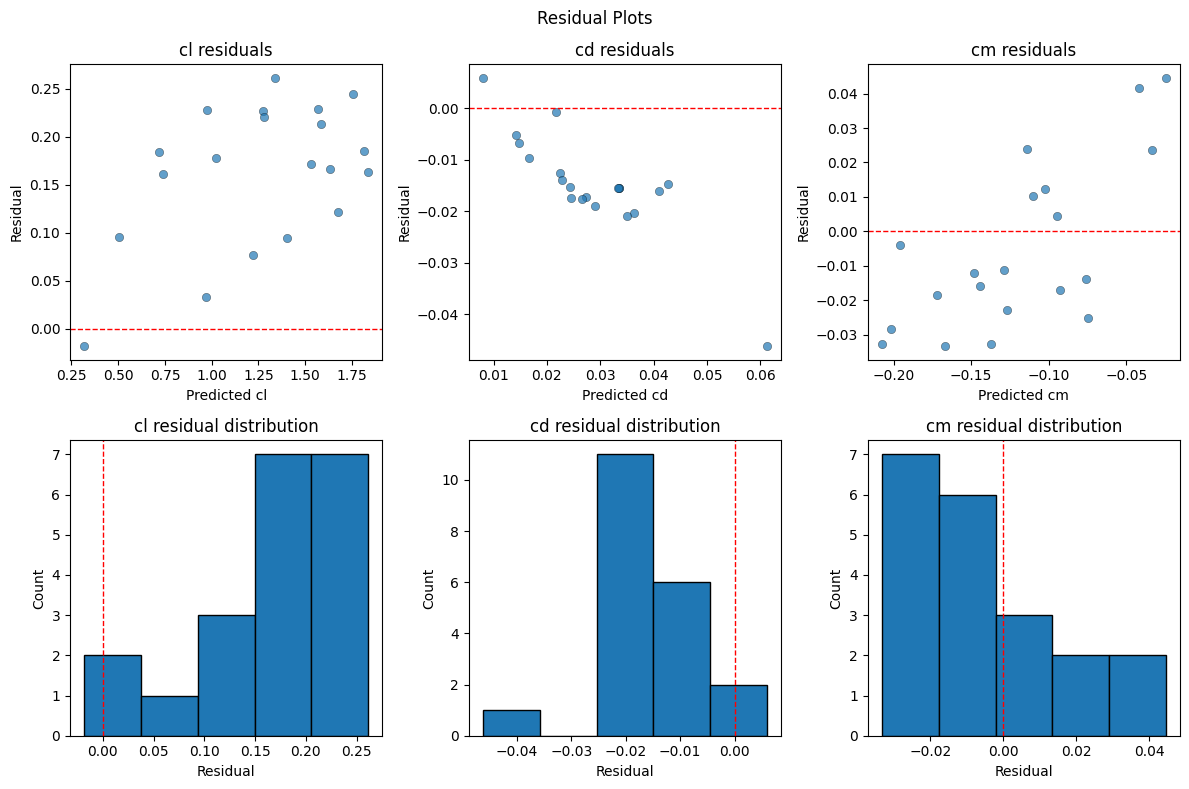

In [22]:
# --- Evaluation block ---
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

labels = ['cl', 'cd', 'cm']

# 1) Basic test metrics
test_loss, test_mae = model.evaluate(x_test, y_test, verbose=0)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

# 2) Predictions
y_pred = model.predict(x_test, verbose=0)  # (N, 3)
y_true = y_test                            # (N, 3)

# 3) Per-output metrics
print("\nPer-output metrics:")
for i, name in enumerate(labels):
    mae  = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2   = r2_score(y_true[:, i], y_pred[:, i])
    print(f"  {name}: MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")

# 4) Predicted vs Actual scatter per output
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, (ax, name) in enumerate(zip(axes, labels)):
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.7, edgecolors='k', linewidths=0.3)
    mn, mx = y_true[:, i].min(), y_true[:, i].max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1)  # perfect prediction line
    ax.set_xlabel(f"Actual {name}")
    ax.set_ylabel(f"Predicted {name}")
    ax.set_title(f"{name} — R²={r2_score(y_true[:, i], y_pred[:, i]):.3f}")
plt.suptitle("Predicted vs Actual")
plt.tight_layout()
plt.show()

# 5) Residuals — scatter + histogram
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, name in enumerate(labels):
    residuals = y_true[:, i] - y_pred[:, i]

    # Scatter
    axes[0, i].scatter(y_pred[:, i], residuals, alpha=0.7, edgecolors='k', linewidths=0.3)
    axes[0, i].axhline(0, color='r', linestyle='--', linewidth=1)
    axes[0, i].set_xlabel(f"Predicted {name}")
    axes[0, i].set_ylabel("Residual")
    axes[0, i].set_title(f"{name} residuals")

    # Histogram
    axes[1, i].hist(residuals, bins=5, edgecolor='k')
    axes[1, i].axvline(0, color='r', linestyle='--', linewidth=1)
    axes[1, i].set_xlabel("Residual")
    axes[1, i].set_ylabel("Count")
    axes[1, i].set_title(f"{name} residual distribution")

plt.suptitle("Residual Plots")
plt.tight_layout()
plt.show()



### Baseline Model with Thin Airfoil Theory

### Draw Airfoil Test

In [ ]:
# If needed once:
# %pip install ipycanvas

import numpy as np
from PIL import Image
from IPython.display import display, HTML
import ipywidgets as widgets
from ipycanvas import Canvas
from IPython.display import clear_output

CANVAS_W, CANVAS_H = 280, 280
MODEL_W,  MODEL_H  = 128, 128
N_MC = 50           # MC Dropout passes
LABELS = ['Cl', 'Cd', 'Cm']

# --- UI ---
canvas     = Canvas(width=CANVAS_W, height=CANVAS_H, sync_image_data=True)
output     = widgets.Output()
btn_predict = widgets.Button(description="Predict",  button_style="primary")
btn_clear   = widgets.Button(description="Clear")

drawing = {"active": False}

def reset_canvas():
    canvas.fill_style  = "black"
    canvas.fill_rect(0, 0, CANVAS_W, CANVAS_H)
    canvas.stroke_style = "white"
    canvas.line_width   = 6      # thinner than digit widget — airfoil is a fine curve
    canvas.line_cap     = "round"
    canvas.line_join    = "round"

reset_canvas()

def on_mouse_down(x, y):
    drawing["active"] = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if not drawing["active"]:
        return
    canvas.line_to(x, y)
    canvas.stroke()

def on_mouse_up(x, y):
    drawing["active"] = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def on_clear(_):
    reset_canvas()
    with output:
        output.clear_output(wait=True)
        print("Canvas cleared.")

def _mc_predict(m, x, n=N_MC):
    """n forward passes with dropout active → mean and std per output."""
    runs = np.stack([m(x, training=True).numpy() for _ in range(n)], axis=0)  # (n, 1, 3)
    return runs.mean(axis=0)[0], runs.std(axis=0)[0]   # each shape (3,)

def on_predict(_):
    # --- canvas → 128×128 float32 tensor ---
    rgba = np.array(canvas.get_image_data(0, 0, CANVAS_W, CANVAS_H), dtype=np.uint8)
    gray = rgba[:, :, 0]   # white-on-black: red channel == brightness
    img  = Image.fromarray(gray, mode="L").resize((MODEL_W, MODEL_H), Image.LANCZOS)
    x    = np.array(img).astype("float32") / 255.0
    x    = x[np.newaxis, :, :, np.newaxis]   # (1, 128, 128, 1)

    mean, std = _mc_predict(model, x)

    # Confidence: how large is the uncertainty relative to the prediction magnitude?
    # conf = |mean| / (|mean| + std), mapped to 0–100 %.
    # Approaches 100 % when std << |mean|, 50 % when std == |mean|.
    conf = 100.0 * np.abs(mean) / (np.abs(mean) + std + 1e-9)

    rows = ""
    for name, mu, sigma, c in zip(LABELS, mean, std, conf):
        bar_w = int(c * 1.5)   # max 150 px
        bar_color = "#4caf50" if c >= 70 else "#ff9800" if c >= 40 else "#f44336"
        rows += f"""
        <tr style='border-bottom:1px solid #e0e0e0'>
          <td style='padding:6px 14px;font-weight:700;font-size:16px'>{name}</td>
          <td style='padding:6px 14px;text-align:right;font-size:15px'>{mu:+.4f}</td>
          <td style='padding:6px 14px;text-align:right;color:#888;font-size:13px'>±{sigma:.4f}</td>
          <td style='padding:6px 14px'>
            <div style='display:flex;align-items:center;gap:8px'>
              <div style='background:{bar_color};width:{bar_w}px;height:12px;border-radius:6px'></div>
              <span style='font-size:13px;color:{bar_color};font-weight:600'>{c:.1f}%</span>
            </div>
          </td>
        </tr>"""

    html = f"""
    <div style='font-family:sans-serif;margin-top:8px'>
      <div style='font-size:14px;font-weight:700;margin-bottom:4px'>Predicted Aerodynamic Coefficients</div>
      <table style='border-collapse:collapse;width:100%'>
        <tr style='border-bottom:2px solid #bbb;color:#555;font-size:12px'>
          <th style='padding:4px 14px;text-align:left'>Coeff</th>
          <th style='padding:4px 14px;text-align:right'>Value</th>
          <th style='padding:4px 14px;text-align:right'>±σ</th>
          <th style='padding:4px 14px;text-align:left'>Confidence</th>
        </tr>
        {rows}
      </table>
      <div style='font-size:11px;color:#aaa;margin-top:6px'>
        MC Dropout · {N_MC} passes · conf = |μ| / (|μ| + σ)
      </div>
    </div>"""

    with output:
        output.clear_output(wait=True)
        display(HTML(html))

btn_clear._click_handlers.callbacks.clear()
btn_predict._click_handlers.callbacks.clear()
btn_clear.on_click(on_clear)
btn_predict.on_click(on_predict)

clear_output(wait=True)   # ← wipes old display slots before re-rendering
display(widgets.HBox([btn_clear, btn_predict]))
display(canvas)
display(output)


Canvas(height=280, sync_image_data=True, width=280)

Output()

In [29]:
# %pip install ipycanvas

import numpy as np
from PIL import Image
from IPython.display import display, HTML
import ipywidgets as widgets
from ipycanvas import Canvas
import IPython.display as ipd

CANVAS_W, CANVAS_H = 280, 280
MODEL_W,  MODEL_H  = 128, 128
N_MC    = 50
LABELS  = ['Cl', 'Cd', 'Cm']

canvas      = Canvas(width=CANVAS_W, height=CANVAS_H, sync_image_data=True)
result      = widgets.HTML(value="<i style='color:#aaa'>Draw an airfoil and click Predict</i>")
btn_predict = widgets.Button(description="Predict", button_style="primary")
btn_clear   = widgets.Button(description="Clear")
drawing     = {"active": False}

def reset_canvas():
    canvas.fill_style  = "black"
    canvas.fill_rect(0, 0, CANVAS_W, CANVAS_H)
    canvas.stroke_style = "white"
    canvas.line_width   = 6
    canvas.line_cap     = "round"
    canvas.line_join    = "round"

reset_canvas()

def on_mouse_down(x, y):
    drawing["active"] = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if not drawing["active"]:
        return
    canvas.line_to(x, y)
    canvas.stroke()

def on_mouse_up(x, y):
    drawing["active"] = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def on_clear(_):
    reset_canvas()
    result.value = "<i style='color:#aaa'>Canvas cleared.</i>"

def _mc_predict(m, x, n=N_MC):
    runs = np.stack([m(x, training=True).numpy() for _ in range(n)], axis=0)
    return runs.mean(axis=0)[0], runs.std(axis=0)[0]

def on_predict(_):
    rgba = np.array(canvas.get_image_data(0, 0, CANVAS_W, CANVAS_H), dtype=np.uint8)
    gray = rgba[:, :, 0]
    img  = Image.fromarray(gray, mode="L").resize((MODEL_W, MODEL_H), Image.LANCZOS)
    x    = np.array(img).astype("float32") / 255.0
    x    = x[np.newaxis, :, :, np.newaxis]

    mean, std = _mc_predict(model, x)
    conf = 100.0 * np.abs(mean) / (np.abs(mean) + std + 1e-9)

    rows = ""
    for name, mu, sigma, c in zip(LABELS, mean, std, conf):
        bar_w      = int(c * 1.5)
        bar_color  = "#4caf50" if c >= 70 else "#ff9800" if c >= 40 else "#f44336"
        rows += f"""
        <tr style='border-bottom:1px solid #e0e0e0'>
          <td style='padding:6px 14px;font-weight:700;font-size:16px'>{name}</td>
          <td style='padding:6px 14px;text-align:right;font-size:15px'>{mu:+.4f}</td>
          <td style='padding:6px 14px;text-align:right;color:#888;font-size:13px'>±{sigma:.4f}</td>
          <td style='padding:6px 14px'>
            <div style='display:flex;align-items:center;gap:8px'>
              <div style='background:{bar_color};width:{bar_w}px;height:12px;border-radius:6px'></div>
              <span style='font-size:13px;color:{bar_color};font-weight:600'>{c:.1f}%</span>
            </div>
          </td>
        </tr>"""

    result.value = f"""
    <div style='font-family:sans-serif;margin-top:8px'>
      <div style='font-size:14px;font-weight:700;margin-bottom:4px'>Predicted Aerodynamic Coefficients</div>
      <table style='border-collapse:collapse;width:100%'>
        <tr style='border-bottom:2px solid #bbb;color:#555;font-size:12px'>
          <th style='padding:4px 14px;text-align:left'>Coeff</th>
          <th style='padding:4px 14px;text-align:right'>Value</th>
          <th style='padding:4px 14px;text-align:right'>±σ</th>
          <th style='padding:4px 14px;text-align:left'>Confidence</th>
        </tr>
        {rows}
      </table>
      <div style='font-size:11px;color:#aaa;margin-top:6px'>
        MC Dropout · {N_MC} passes · conf = |μ| / (|μ| + σ)
      </div>
    </div>"""

btn_clear._click_handlers.callbacks.clear()
btn_predict._click_handlers.callbacks.clear()
btn_clear.on_click(on_clear)
btn_predict.on_click(on_predict)

app = widgets.VBox([widgets.HBox([btn_clear, btn_predict]), canvas, result])

# display_id: first run creates the slot; re-runs update it in place — no stacking
if '_airfoil_handle' not in globals():
    _airfoil_handle = ipd.display(app, display_id=True)
else:
    _airfoil_handle.update(app)


## Vision Transformer Modeling

# Working with 9k Dataset Information

## Explore Airfoil Shapes & Parameterizations

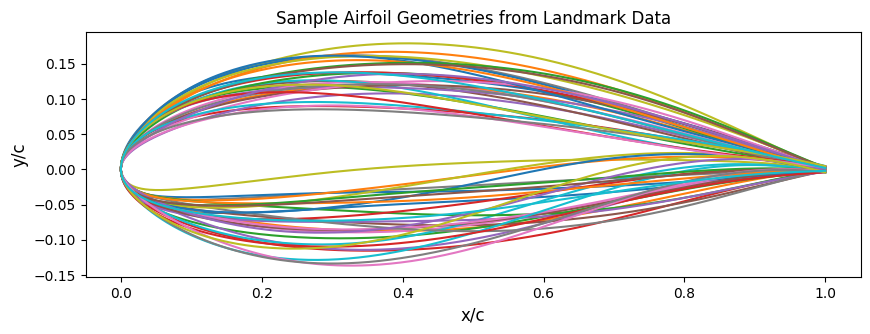

In [ ]:
# clears current figure
# Visualize the first 5 airfoil geometries using the landmarks dataset
plt.figure(figsize=(10, 6))
with h5py.File(data_path, 'r') as hf:
    landmarks = hf['shape']['landmarks'][()]
    af_shape_count = 0
    for landmark in landmarks[0:30]:
        plt.plot(landmark[:, 0], landmark[:, 1], label='airfoil {}'.format(af_shape_count))
        af_shape_count += 1
plt.xlabel('x/c', fontsize=12)
plt.ylabel('y/c', fontsize=12)
plt.gca().set_aspect(1.)
# plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
plt.title('Sample Airfoil Geometries from Landmark Data')
plt.show()


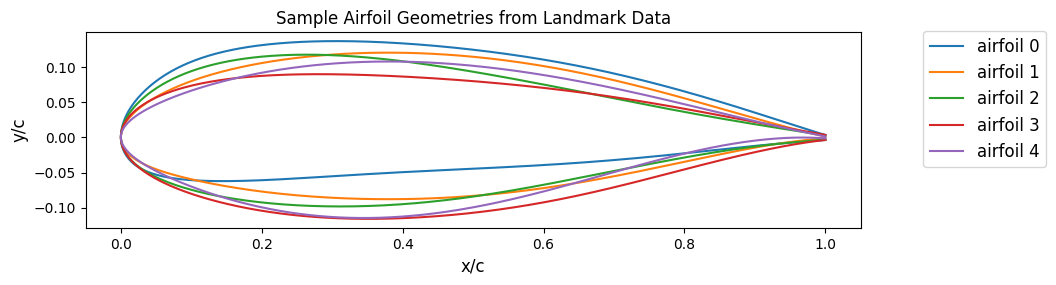

In [ ]:
# plt.close('all')
# # clears current figure
# # Visualize the first 5 airfoil geometries using the landmarks dataset
# plt.figure(figsize=(10, 6))
# with h5py.File(data_path, 'r') as hf:
#     landmarks = hf['shape']['landmarks'][()]
#     af_shape_count = 0
#     for landmark in landmarks[0:20]:
#         plt.plot(landmark[:, 0], landmark[:, 1], label='airfoil {}'.format(af_shape_count))
#         af_shape_count += 1
# plt.xlabel('x/c', fontsize=12)
# plt.ylabel('y/c', fontsize=12)
# plt.gca().set_aspect(1.)
# plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
# plt.title('Sample Airfoil Geometries from Landmark Data')
# plt.show()

import dask.array as da

plt.close('all')
plt.figure(figsize=(10, 6))

with h5py.File(data_path, 'r') as hf:
    landmarks = da.from_array(hf['shape']['landmarks'], chunks=500)
    landmarks_subset = landmarks[0:5].compute()  # only loads 20 rows

for i, landmark in enumerate(landmarks_subset):
    plt.plot(landmark[:, 0], landmark[:, 1], label=f'airfoil {i}')

plt.xlabel('x/c', fontsize=12)
plt.ylabel('y/c', fontsize=12)
plt.gca().set_aspect(1.)
plt.legend(bbox_to_anchor=(1.25, 1.05), fontsize=12)
plt.title('Sample Airfoil Geometries from Landmark Data')
plt.show()


In [ ]:
# # Capture reduced dimensionality parameterizations as objects and print shapes
# with h5py.File(data_path, 'r') as hf:
#     grassmann = hf['shape']['grassmann'][()]
#     print('Grassmann')
#     print(grassmann.shape)
    
#     cst = hf['shape']['cst'][()]
#     print('CST')
#     print(cst.shape)
    
#     bezier = hf['shape']['bezier'][()]
#     print('Bezier')
#     print(bezier.shape)

with h5py.File(data_path, 'r') as hf:
    grassmann = da.from_array(hf['shape']['grassmann'], chunks=500)
    print('Grassmann', grassmann.shape)

    cst = da.from_array(hf['shape']['cst'], chunks=500)
    print('CST', cst.shape)

    bezier = da.from_array(hf['shape']['bezier'], chunks=500)
    print('Bezier', bezier.shape)


Grassmann (8996, 4)
CST (8996, 19)
Bezier (8996, 15)


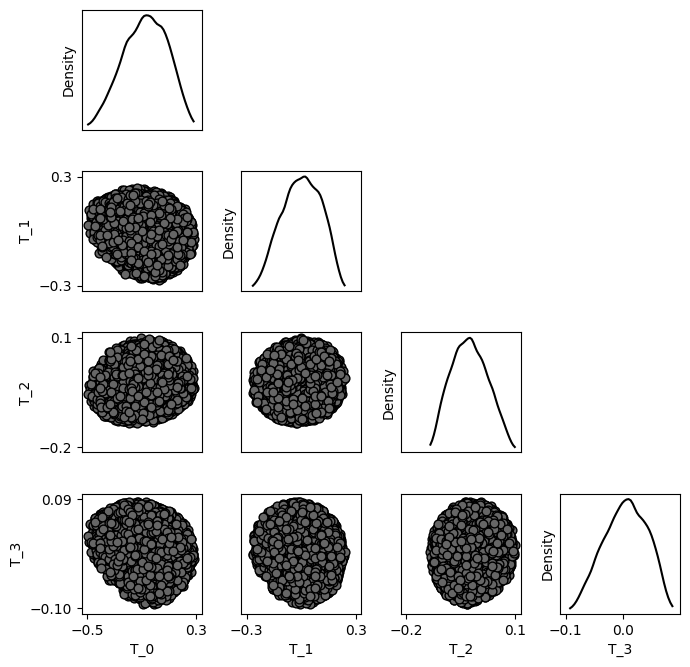

In [ ]:
with h5py.File(data_path, 'r') as hf:
    grassmann = da.from_array(hf['shape']['grassmann'], chunks=500).compute()

## Visualize distributions of Grassmann parameters
m = grassmann.shape[1]
grassmann_limits = []
for i in range(m):
    lower = grassmann[:,i].min()
    upper = grassmann[:,i].max()
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    grassmann_limits.append([lower,upper])

grassmann_labels = ['T_{}'.format(i) for i in range(m)]

plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(grassmann[:,i].min(), grassmann[:,i].max())
            kde = gaussian_kde(grassmann[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(grassmann_limits[i][0]-0.05*np.ptp(grassmann_limits[i]),
                     grassmann_limits[i][-1]+0.05*np.ptp(grassmann_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
            if i == (m-1):
                plt.xlabel(grassmann_labels[j], fontsize=10)
            else:
                plt.xticks([])
        else:
            plt.scatter(grassmann[:,j], grassmann[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(grassmann_limits[j])
            plt.yticks(grassmann_limits[i])
            if i == (m-1):
                plt.xlabel(grassmann_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(grassmann_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(grassmann_limits[j][0]-0.05*np.ptp(grassmann_limits[j]),
                     grassmann_limits[j][-1]+0.05*np.ptp(grassmann_limits[j]))
            plt.ylim(grassmann_limits[i][0]-0.05*np.ptp(grassmann_limits[i]),
                     grassmann_limits[i][-1]+0.05*np.ptp(grassmann_limits[i]))
        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


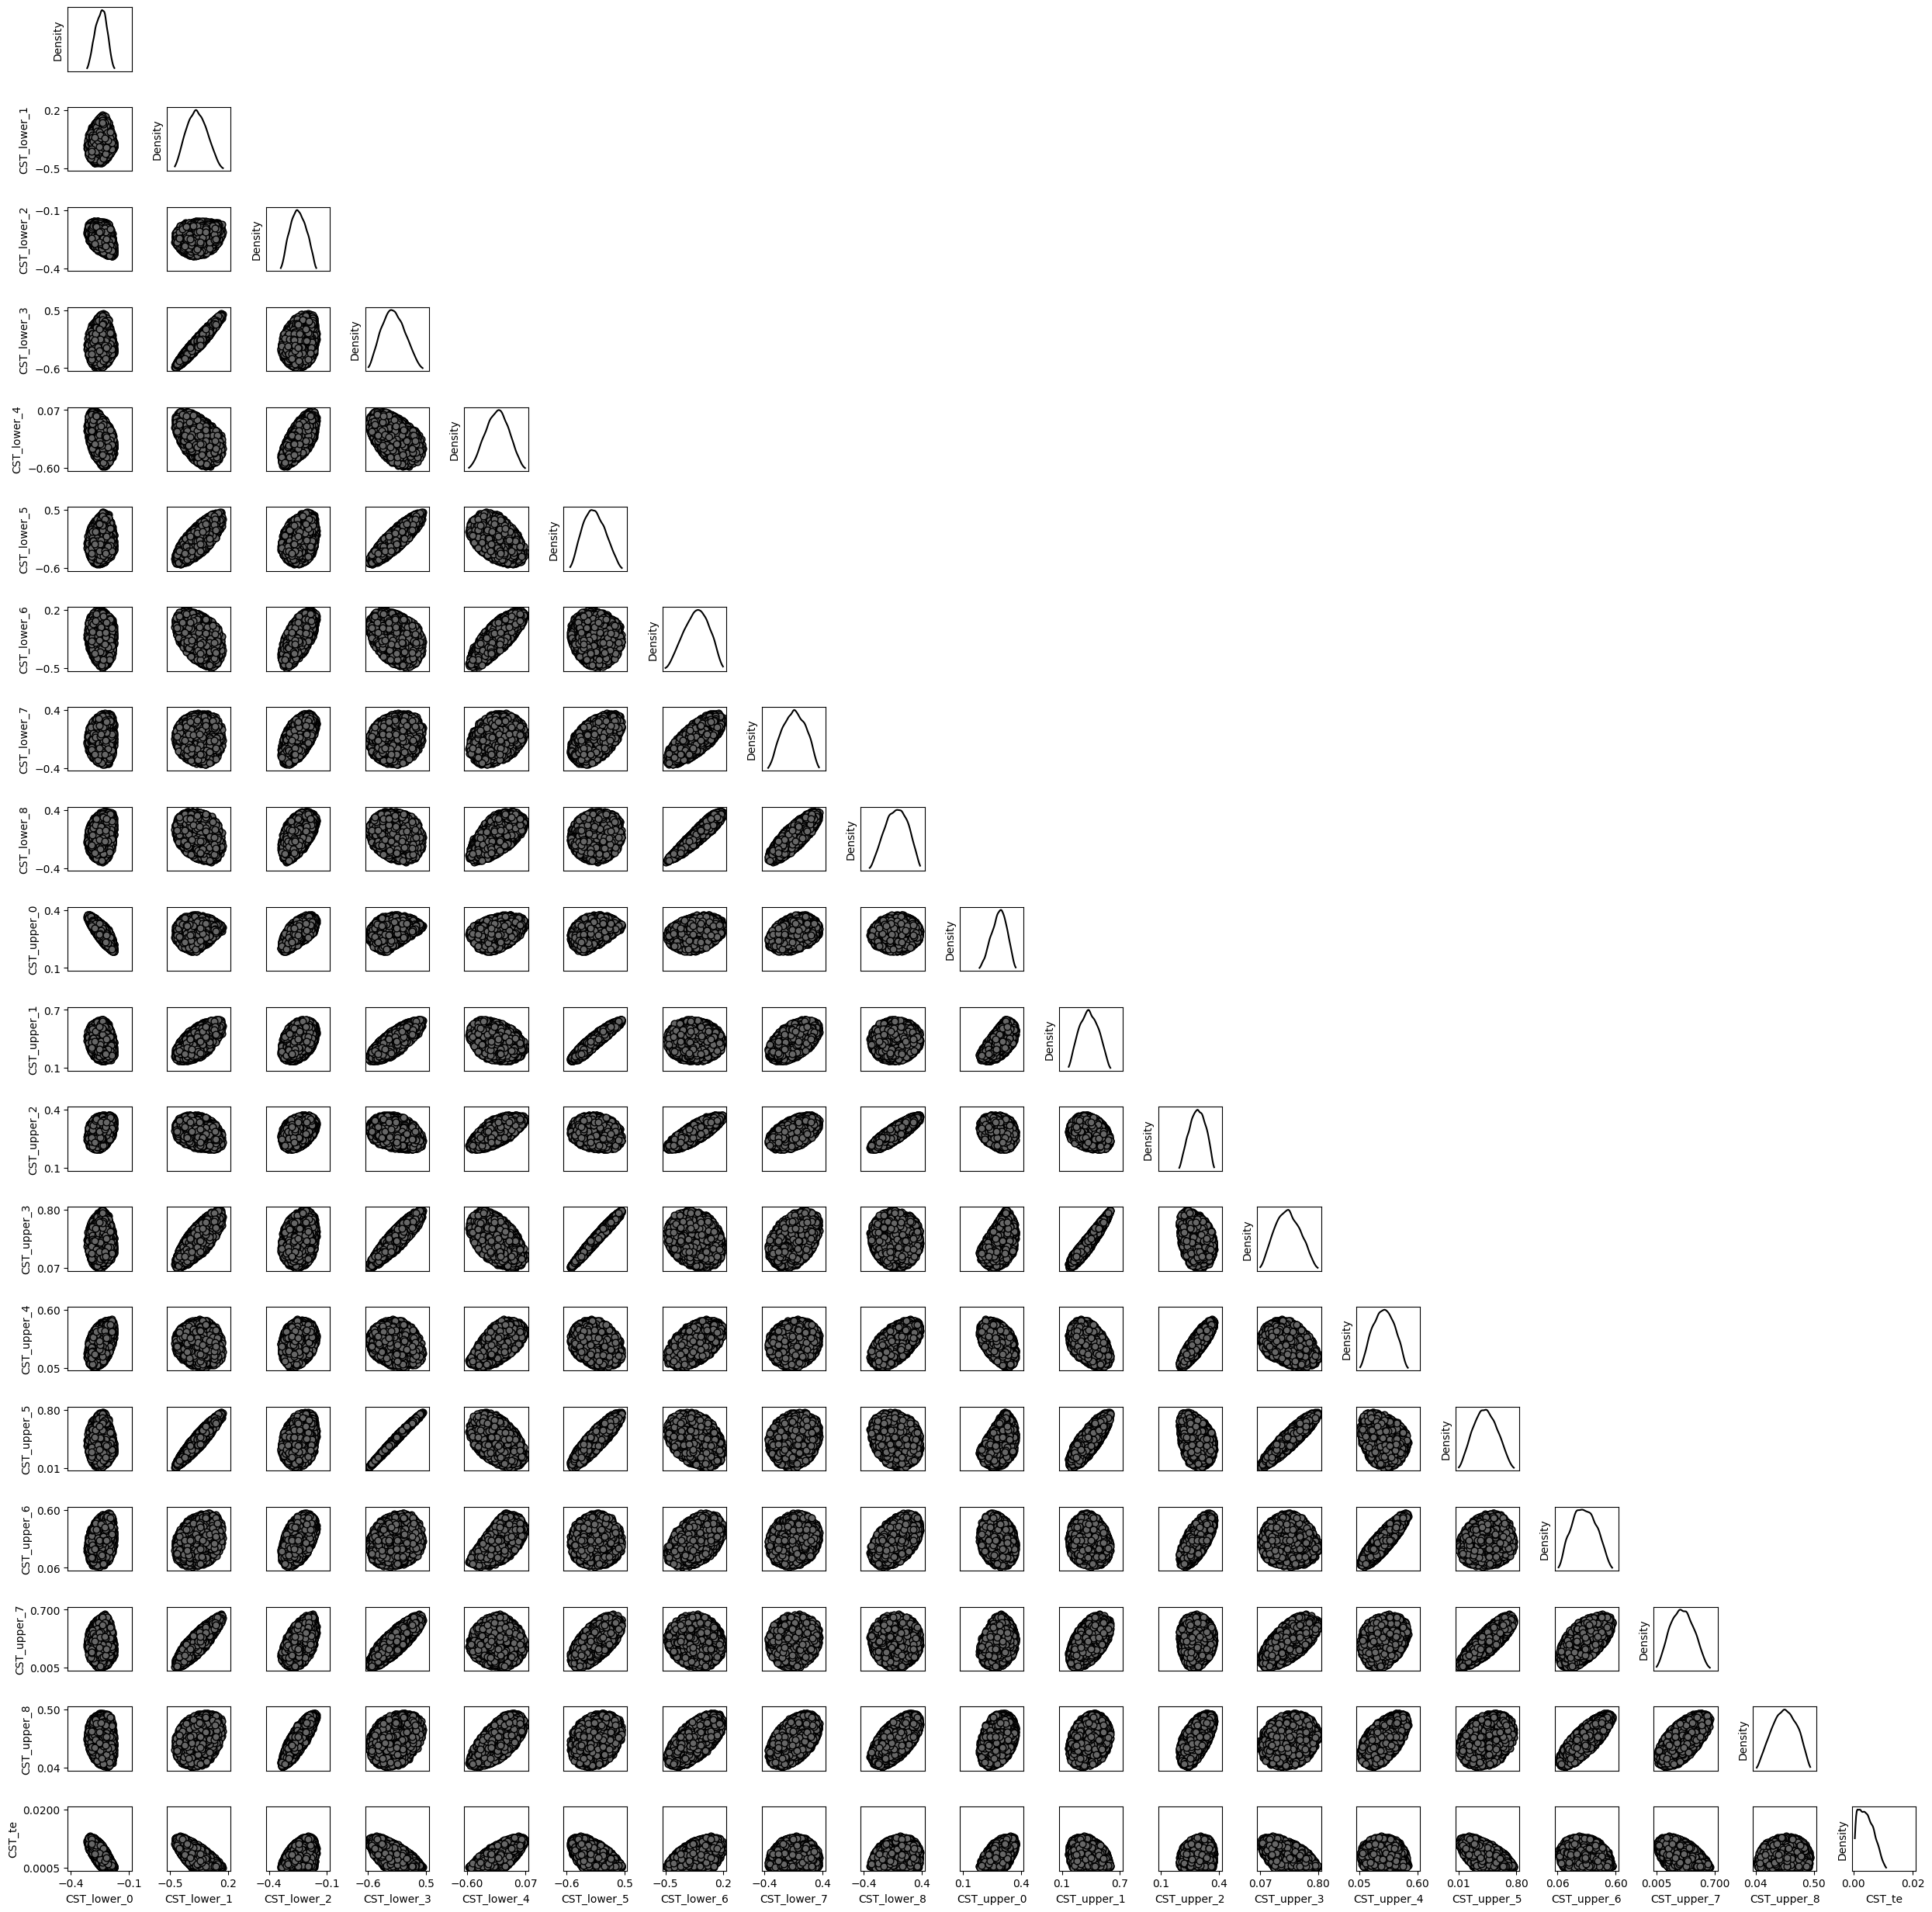

In [ ]:
with h5py.File(data_path, 'r') as hf:
    cst = da.from_array(hf['shape']['cst'], chunks=500).compute()

## Visualize distributions of CST parameters
m = cst.shape[1]
cst_limits = []
for i in range(m):
    lower = cst[:,i].min()
    upper = cst[:,i].max()
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    cst_limits.append([lower,upper])

cst_labels = ['CST_lower_{}'.format(i) for i in range(int((m-1)/2))]
cst_labels.extend(['CST_upper_{}'.format(i) for i in range(int((m-1)/2))])
cst_labels.extend(['CST_te'])

plt.figure(figsize=(25,25))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(cst[:,i].min(), cst[:,i].max())
            kde = gaussian_kde(cst[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
        else:
            plt.scatter(cst[:,j], cst[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(cst_limits[j])
            plt.yticks(cst_limits[i])
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(cst_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(cst_limits[j][0]-0.05*np.ptp(cst_limits[j]),
                     cst_limits[j][-1]+0.05*np.ptp(cst_limits[j]))
            plt.ylim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


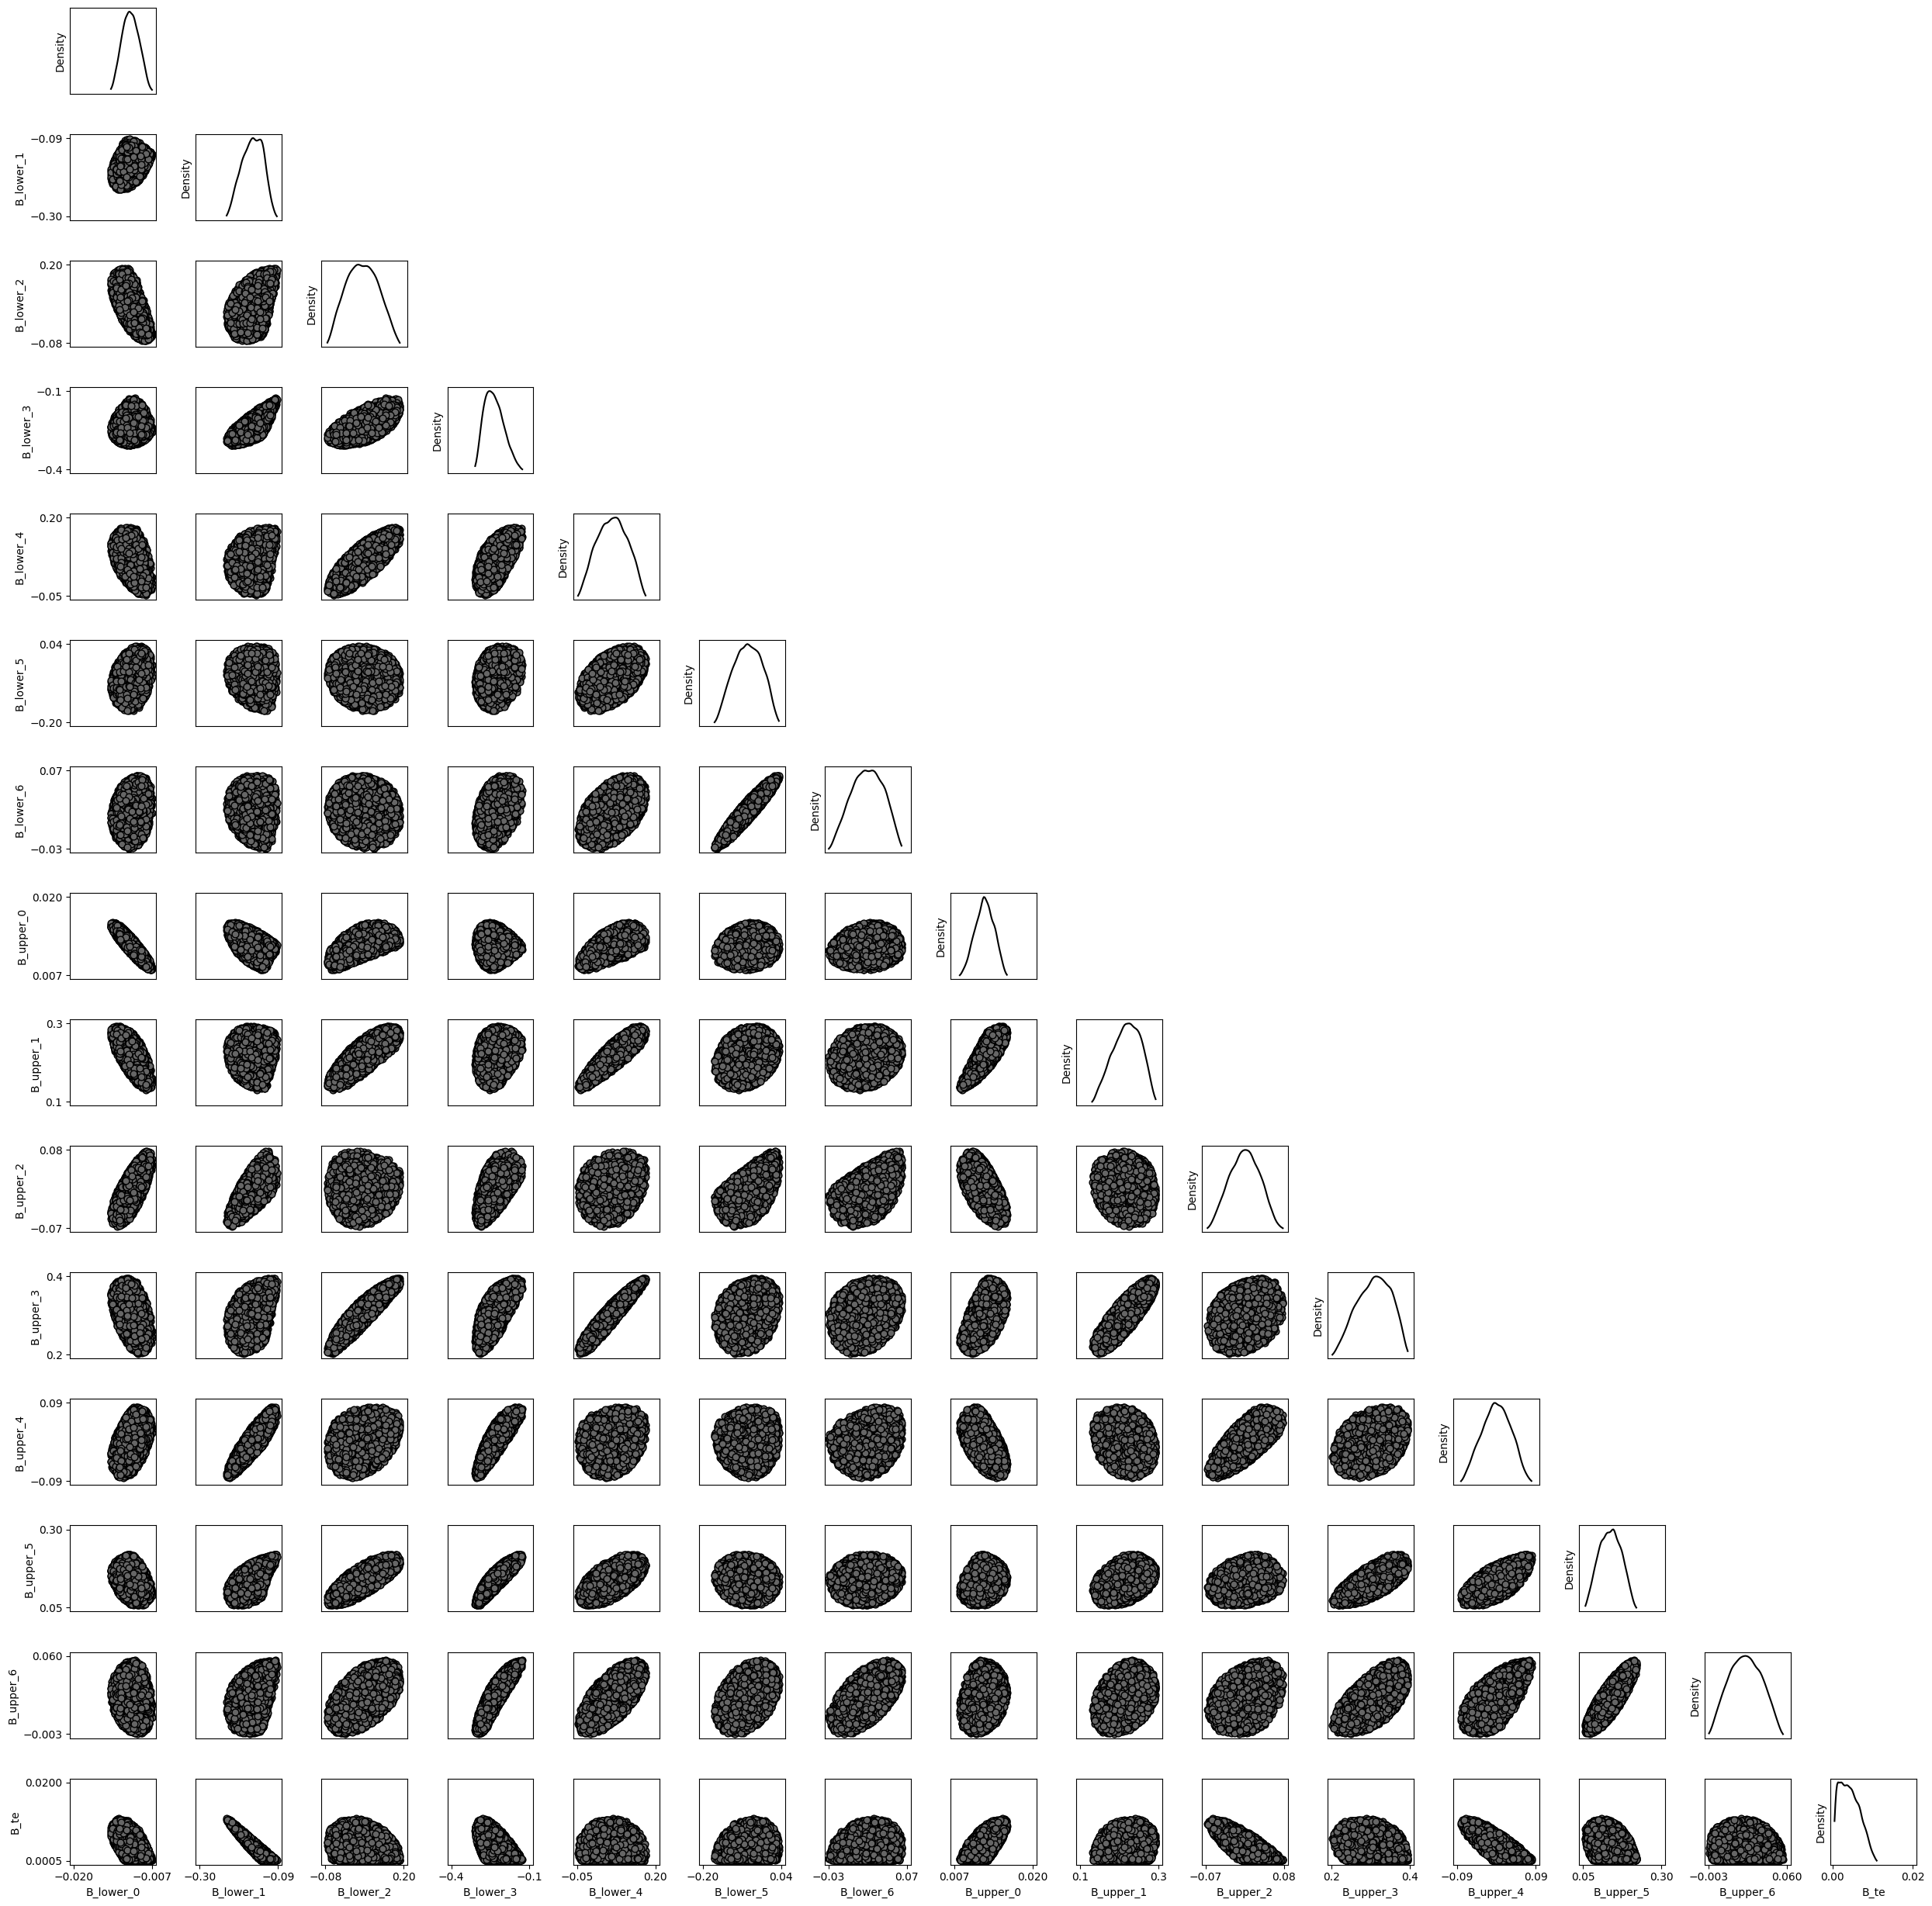

In [ ]:
with h5py.File(data_path, 'r') as hf:
    bezier = da.from_array(hf['shape']['bezier'], chunks=500).compute()

## Visualize distributions of Bezier curve parameters
# Capture number of parameters in bezier representation
m = bezier.shape[1]
# Create list to hold upper and lower limits for visualizations
bezier_limits = []
for i in range(m):
    # Capture min and max values in each bezier parameter across all airfoils
    lower = bezier[:,i].min()
    upper = bezier[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    bezier_limits.append([lower,upper])

# Create labels for bezier parameters
bezier_labels = ['B_lower_{}'.format(i) for i in range(int((m-1)/2))]
bezier_labels.extend(['B_upper_{}'.format(i) for i in range(int((m-1)/2))])
bezier_labels.extend(['B_te'])

# Plot marginal distributions of the bezier data
plt.figure(figsize=(25,25))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(bezier[:,i].min(), bezier[:,i].max())
            kde = gaussian_kde(bezier[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]),
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(bezier[:,j], bezier[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(bezier_limits[j])
            plt.yticks(bezier_limits[i])
            
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(bezier_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(bezier_limits[j][0]-0.05*np.ptp(bezier_limits[j]), 
                     bezier_limits[j][-1]+0.05*np.ptp(bezier_limits[j]))
            plt.ylim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]), 
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


## Airfoil Shape and Aerodynamic Properties

In [ ]:
# # Parse the landmark datasets and extract thickness along the chord and camber line
# with h5py.File(data_path, 'r') as hf:    
#     landmarks = hf['shape']['landmarks'][()]
#     N_airfoils = landmarks.shape[0]
with h5py.File(data_path, 'r') as hf:
    landmarks = da.from_array(hf['shape']['landmarks'], chunks=500).compute()
    N_airfoils = landmarks.shape[0]

    
    # Calculate thickness at each x_c step except for the leading edge (x_c~0.0, index 500, axis=1)
    thickness_arr_2d = abs(landmarks[:,501:,1] - np.flip(landmarks[:,:500,1],axis=1))
    
    # Calculate camber / midpoint at each x_c step
    camber_arr_2d = (landmarks[:,501:,1] + np.flip(landmarks[:,:500,1],axis=1))/2
    
    # Create numpy array to represent x_c values at each thickness/camber step (0.002 increments between 0.002 and 1.0 inclusive)
    x_c_arr = np.resize(np.arange(0.002,1.002,0.002), thickness_arr_2d.shape[0]*500)

    # Reshape thickness array such that each row is one thickness value totaling 8996 airfoils * 500 landmarks per foil, output shape = (4498500,1)
    thickness_arr_1d = np.reshape(thickness_arr_2d, (N_airfoils*500,1))
    
    # Insert x_c value indexes in 0th column --> output shape = (4498500,2) 
    thickness_arr_1d = np.insert(thickness_arr_1d, 0, x_c_arr, axis=1)

    # Reshape camber array such that each row is one camber value totaling 8996 airfoils * 500 landmarks per foil (4498500,1)
    camber_arr_1d = np.reshape(camber_arr_2d, (N_airfoils*500,1))
    
    # Insert x_c value indexes in first 0th column --> (4498500,2) output
    camber_arr_1d = np.insert(camber_arr_1d, 0, x_c_arr, axis=1)


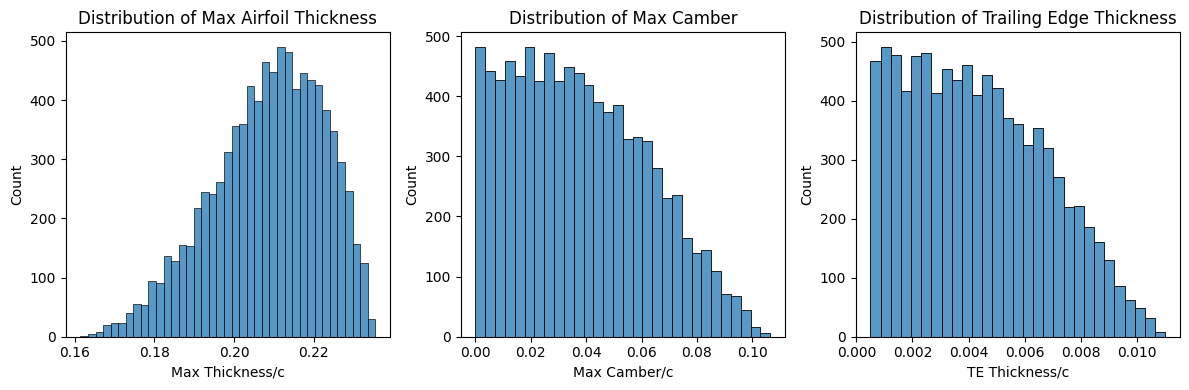

In [ ]:
# Visualize distribution of maximum thickness/maximum camber/trailing edge thickness across airfoils
plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = sns.histplot(data=np.max(thickness_arr_2d, axis=1), stat='count')
ax.set_title('Distribution of Max Airfoil Thickness')
ax.set(xlabel='Max Thickness/c')

plt.subplot(132)
ax = sns.histplot(data=np.max(camber_arr_2d, axis=1), stat='count')
ax.set_title('Distribution of Max Camber')
ax.set(xlabel='Max Camber/c')

plt.subplot(133)
ax = sns.histplot(data=thickness_arr_2d[:,499], stat='count')
ax.set_title('Distribution of Trailing Edge Thickness')
ax.set(xlabel='TE Thickness/c')

plt.tight_layout()
plt.show()

In [28]:
# # Visualize average thickness along the chord and standard deviation across all airfoils
# plt.figure(figsize=(12, 4))

# plt.subplot(121)
# ax = sns.lineplot(data=thickness_arr_1d, x=thickness_arr_1d[:,0], y=thickness_arr_1d[:,1], 
#                   errorbar='sd', n_boot=(len(thickness_arr_1d)))
# ax.set(xlabel='x/c', ylabel='thickness/c')
# ax.set_title('Avg Airfoil Thickness along the Chord')

# plt.subplot(122)
# ax = sns.lineplot(data=camber_arr_1d, x=camber_arr_1d[:,0], y=camber_arr_1d[:,1], 
#                   errorbar='sd', n_boot=(len(camber_arr_1d)))
# ax.set(xlabel='x/c', ylabel='camber/c')
# ax.set_title('Avg Camber Line along the Chord')
# ax.set_ylim(ymin=-0.025, ymax=0.10)

# plt.tight_layout()
# plt.show()

import pandas as pd

thickness_df = pd.DataFrame(thickness_arr_1d, columns=['x', 'thickness'])
camber_df = pd.DataFrame(camber_arr_1d, columns=['x', 'camber'])

plt.figure(figsize=(12, 4))

plt.subplot(121)
ax = sns.lineplot(data=thickness_df, x='x', y='thickness', errorbar='sd', n_boot=len(thickness_df))
ax.set(xlabel='x/c', ylabel='thickness/c')
ax.set_title('Avg Airfoil Thickness along the Chord')

plt.subplot(122)
ax = sns.lineplot(data=camber_df, x='x', y='camber', errorbar='sd', n_boot=len(camber_df))
ax.set(xlabel='x/c', ylabel='camber/c')
ax.set_title('Avg Camber Line along the Chord')
ax.set_ylim(ymin=-0.025, ymax=0.10)

plt.tight_layout()
plt.show()


NameError: name 'thickness_arr_1d' is not defined

C:\Users\Enzo\AppData\Local\Temp\ipykernel_29632\3692024427.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([4,12])
C:\Users\Enzo\AppData\Local\Temp\ipykernel_29632\3692024427.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([4,12])
C:\Users\Enzo\AppData\Local\Temp\ipykernel_29632\3692024427.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([4,12])


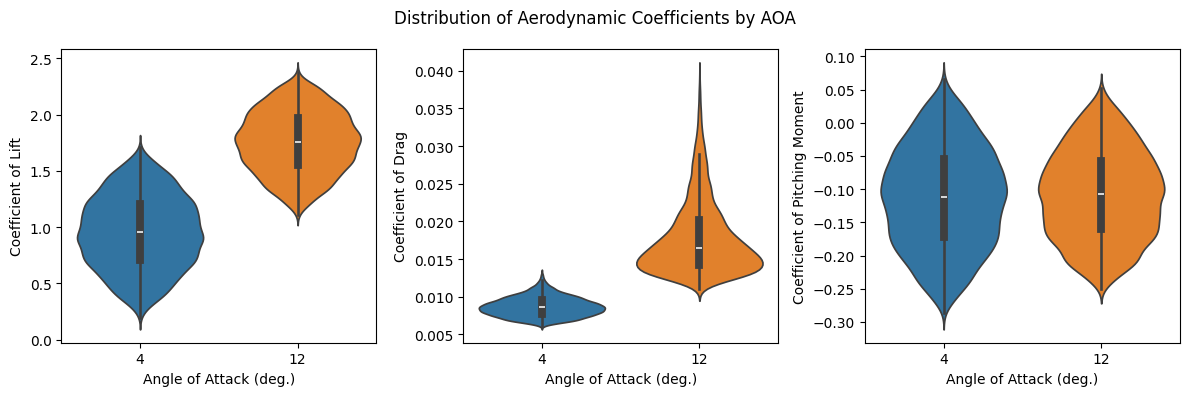

In [ ]:
# Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
with h5py.File(data_path, 'r') as hf:
    cl_alpha04 = da.from_array(hf['alpha+04']['C_l'], chunks=500).compute()
    cd_alpha04 = da.from_array(hf['alpha+04']['C_d'], chunks=500).compute()
    cm_alpha04 = da.from_array(hf['alpha+04']['C_m'], chunks=500).compute()

    cl_alpha12 = da.from_array(hf['alpha+12']['C_l'], chunks=500).compute()
    cd_alpha12 = da.from_array(hf['alpha+12']['C_d'], chunks=500).compute()
    cm_alpha12 = da.from_array(hf['alpha+12']['C_m'], chunks=500).compute()

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = sns.violinplot(data=[cl_alpha04, cl_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = sns.violinplot(data=[cd_alpha04, cd_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = sns.violinplot(data=[cm_alpha04, cm_alpha12])
ax.set_xticklabels([4,12])
plt.xlabel('Angle of Attack (deg.)')
plt.ylabel('Coefficient of Pitching Moment')

plt.suptitle('Distribution of Aerodynamic Coefficients by AOA')
plt.tight_layout()
plt.show()

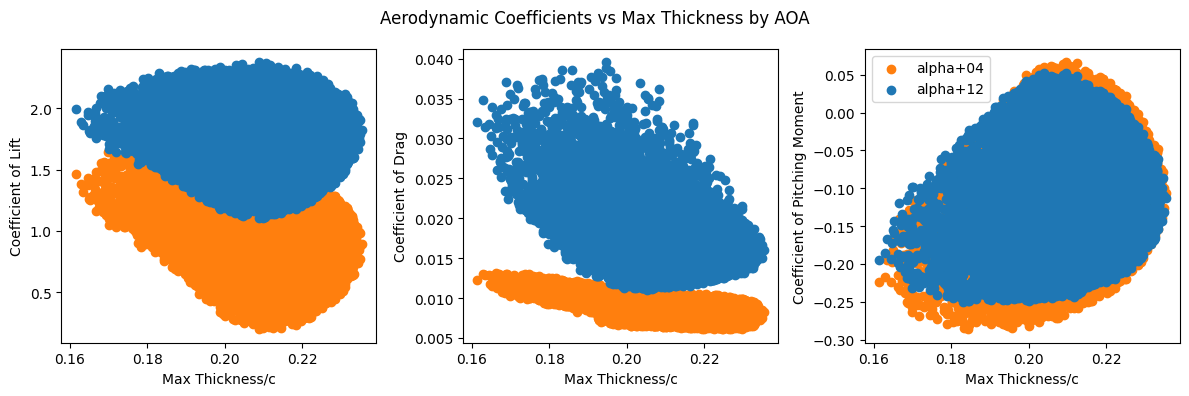

In [ ]:
# # Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
# with h5py.File(data_path, 'r') as hf:
#         cl_alpha04 = hf['alpha+04']['C_l'][()]
#         cd_alpha04 = hf['alpha+04']['C_d'][()]
#         cm_alpha04 = hf['alpha+04']['C_m'][()]
        
#         cl_alpha12 = hf['alpha+12']['C_l'][()]
#         cd_alpha12 = hf['alpha+12']['C_d'][()]
#         cm_alpha12 = hf['alpha+12']['C_m'][()]

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cl_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cl_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cd_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cd_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cm_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(thickness_arr_2d, axis=1), y=cm_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Thickness/c')
plt.ylabel('Coefficient of Pitching Moment')

plt.legend(loc='upper left')
plt.suptitle('Aerodynamic Coefficients vs Max Thickness by AOA')
plt.tight_layout()
plt.show()

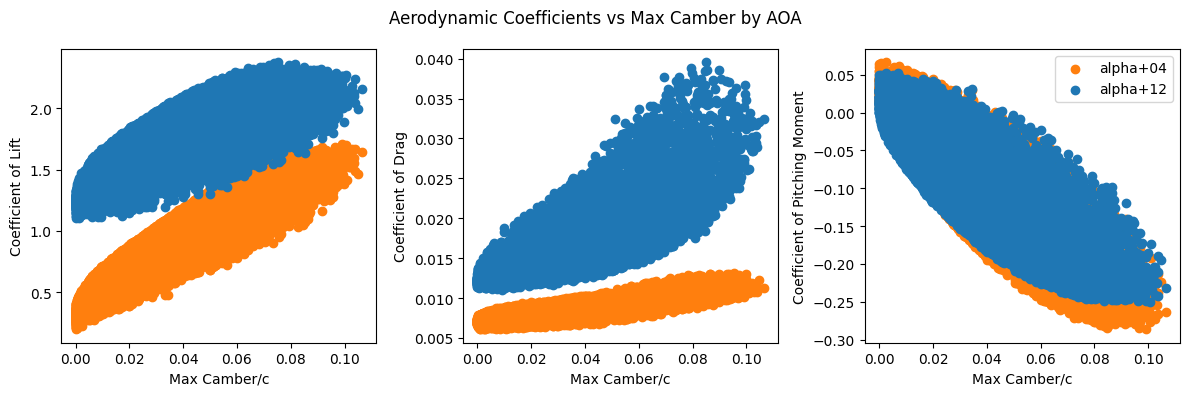

In [ ]:
# # Visualize distributions of coeffients of lift, drag, and moment as a function of angle of attack across all airfoils
# with h5py.File(data_path, 'r') as hf:
#         cl_alpha04 = hf['alpha+04']['C_l'][()]
#         cd_alpha04 = hf['alpha+04']['C_d'][()]
#         cm_alpha04 = hf['alpha+04']['C_m'][()]
        
#         cl_alpha12 = hf['alpha+12']['C_l'][()]
#         cd_alpha12 = hf['alpha+12']['C_d'][()]
#         cm_alpha12 = hf['alpha+12']['C_m'][()]

plt.figure(figsize=(12, 4))

plt.subplot(131)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cl_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cl_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Lift')

plt.subplot(132)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cd_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cd_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Drag')

plt.subplot(133)
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cm_alpha04, c='tab:orange', label='alpha+04')
ax = plt.scatter(x=np.max(camber_arr_2d, axis=1), y=cm_alpha12, c='tab:blue', label='alpha+12')
plt.xlabel('Max Camber/c')
plt.ylabel('Coefficient of Pitching Moment')

plt.suptitle('Aerodynamic Coefficients vs Max Camber by AOA')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Dimension Reduction of Parameterizations

--------------------------------------------------
Number of Components = 1
Explained Variance:
[7.2918174]
--------------------------------------------------
Number of Components = 2
Explained Variance:
[7.2918174  6.36463173]
--------------------------------------------------
Number of Components = 3
Explained Variance:
[7.2918174  6.36463173 3.42187149]
--------------------------------------------------
Number of Components = 4
Explained Variance:
[7.2918174  6.36463173 3.42187149 1.86004761]
--------------------------------------------------
Number of Components = 5
Explained Variance:
[7.2918174  6.36463173 3.42187149 1.86004761 0.05012966]


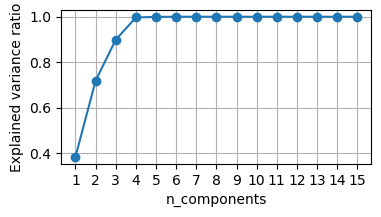

In [ ]:
## Explore the PCA space of the cst data
# Aim to reduce cst data down to same dimensionality as the grassmann data (8996, 4)
# Standardize the data with zero mean and unity variance
std_scaler = StandardScaler()
cst_std = std_scaler.fit_transform(cst)

# Loop through all possible # of components for the PCA given the shape of the data
n_comps = np.arange(15)+1
var_ratio = []
for i in n_comps:
    pca = PCA(n_components=i)
    pca.fit(cst_std)
    # Capture explained variance ratio for visualizations
    var_ratio.append(np.sum(pca.explained_variance_ratio_))
    # print explained variance for n_components < 6
    if i < 6 :
        print("--------------------------------------------------")
        print("Number of Components =", i)
        print("Explained Variance:")
        print(pca.explained_variance_)

plt.figure(figsize=(4,2))
plt.grid()
plt.plot(n_comps,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.xticks([int(i) for i in n_comps])

plt.show()

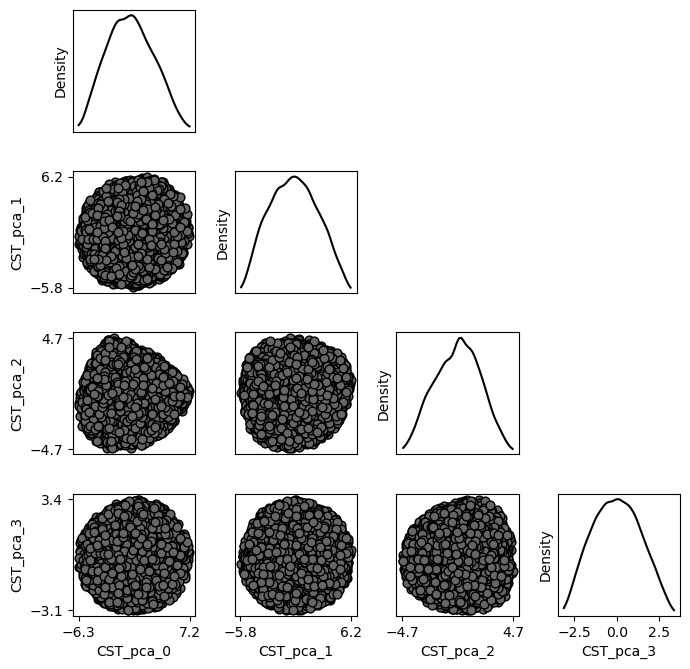

In [ ]:
# Transform standardized cst data to (8996, 4) via PCA
pca = PCA(n_components=4)
cst_pca = pca.fit_transform(cst_std)

## Visualize distributions of CST parameters
# Capture number of parameters in CST representation
m = cst_pca.shape[1]
# Create list to hold upper and lower limits for visualizations
cst_limits = []
for i in range(m):
    # Capture min and max values in each CST parameter across all airfoils
    lower = cst_pca[:,i].min()
    upper = cst_pca[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    cst_limits.append([lower,upper])

# Create labels for CST parameters
cst_labels = ['CST_pca_{}'.format(i) for i in range(int((m)))]


# Plot marginal distributions of the CST data
plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(cst_pca[:,i].min(), cst_pca[:,i].max())
            kde = gaussian_kde(cst_pca[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]),
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(cst_pca[:,j], cst_pca[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(cst_limits[j])
            plt.yticks(cst_limits[i])
            
            if i == (m-1):
                plt.xlabel(cst_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(cst_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(cst_limits[j][0]-0.05*np.ptp(cst_limits[j]), 
                     cst_limits[j][-1]+0.05*np.ptp(cst_limits[j]))
            plt.ylim(cst_limits[i][0]-0.05*np.ptp(cst_limits[i]), 
                     cst_limits[i][-1]+0.05*np.ptp(cst_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


--------------------------------------------------
Number of Components = 1
Explained Variance:
[6.65828063]
--------------------------------------------------
Number of Components = 2
Explained Variance:
[6.65828063 4.71747706]
--------------------------------------------------
Number of Components = 3
Explained Variance:
[6.65828063 4.71747706 2.54334009]
--------------------------------------------------
Number of Components = 4
Explained Variance:
[6.65828063 4.71747706 2.54334009 1.05282004]
--------------------------------------------------
Number of Components = 5
Explained Variance:
[6.65828063 4.71747706 2.54334009 1.05282004 0.02648279]


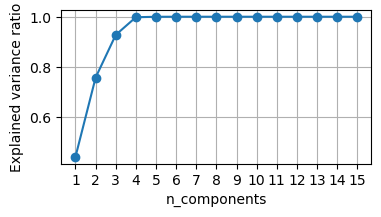

In [ ]:
## Explore the PCA space of the bezier data
# Aim to reduce bezier data down to same dimensionality as the grassmann data (8996, 4)
# Standardize the data with zero mean and unity variance
std_scaler = StandardScaler()
bezier_std = std_scaler.fit_transform(bezier)

# Loop through all possible # of components for the PCA given the shape of the data
n_comps = np.arange(15)+1
var_ratio = []
for i in n_comps:
    pca = PCA(n_components=i)
    pca.fit(bezier_std)
    # Capture explained variance ratio for visualizations
    var_ratio.append(np.sum(pca.explained_variance_ratio_))
    # print explained variance for n_components < 6
    if i < 6 :
        print("--------------------------------------------------")
        print("Number of Components =", i)
        print("Explained Variance:")
        print(pca.explained_variance_)

plt.figure(figsize=(4,2))
plt.grid()
plt.plot(n_comps,var_ratio,marker='o')
plt.xlabel('n_components')
plt.ylabel('Explained variance ratio')
plt.xticks([int(i) for i in n_comps])

plt.show()

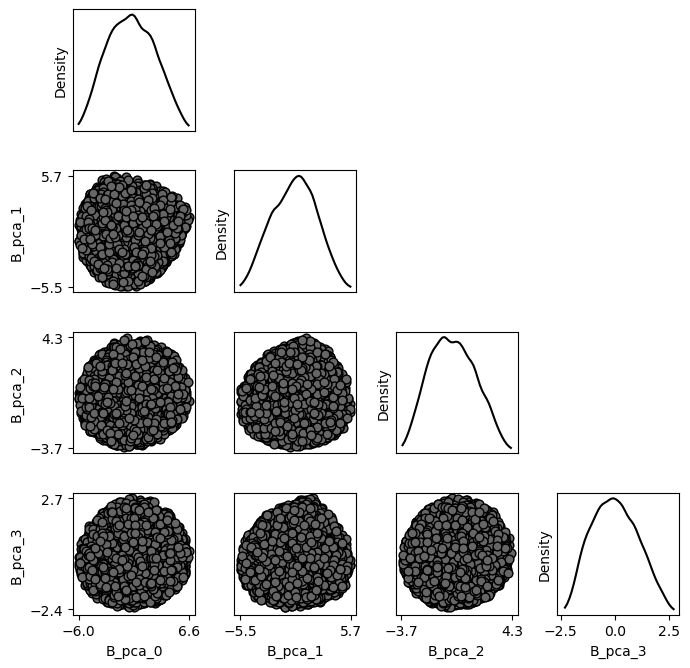

In [ ]:
# Transform standardized bezier data to (8996, 4) via PCA
pca = PCA(n_components=4)
bezier_pca = pca.fit_transform(bezier_std)


## Visualize distributions of PCA Bezier curve parameters
# Capture number of parameters in bezier representation
m = bezier_pca.shape[1]
# Create list to hold upper and lower limits for visualizations
bezier_limits = []
for i in range(m):
    # Capture min and max values in each bezier parameter across all airfoils
    lower = bezier_pca[:,i].min()
    upper = bezier_pca[:,i].max()
    # determine position of first non-zero digit after the decimal place, perform ceiling and floor rounding to that precision
    lower = rounders.floor(lower,(abs(int(math.log10(abs(lower))))+1))
    upper = rounders.ceil(upper,(abs(int(math.log10(abs(upper))))+1))
    # append parameter lower and upper limits to list
    bezier_limits.append([lower,upper])

# Create labels for bezier parameters
bezier_labels = ['B_pca_{}'.format(i) for i in range(int((m)))]

# Plot marginal distributions of the bezier data
plt.figure(figsize=(7, 7))
for i in range(m):
    for j in range(i+1):
        plt.subplot(m, m, (m*i)+j+1)
        if i == j:
            vals = np.linspace(bezier_pca[:,i].min(), bezier_pca[:,i].max())
            kde = gaussian_kde(bezier_pca[:,i])
            plt.plot(vals,kde(vals),'k')
            plt.xlim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]),
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))
            plt.yticks([])
            plt.ylabel('Density')
        
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])

        else:
            plt.scatter(bezier_pca[:,j], bezier_pca[:,i], s=40, c=[[0.4,0.4,0.4]], edgecolor='k')
            plt.xticks(bezier_limits[j])
            plt.yticks(bezier_limits[i])
            
            if i == (m-1):
                plt.xlabel(bezier_labels[j], fontsize=10)
            else:
                plt.xticks([])
            if j == 0:
                plt.ylabel(bezier_labels[i], fontsize=10)
            else:
                plt.yticks([])
            plt.xlim(bezier_limits[j][0]-0.05*np.ptp(bezier_limits[j]), 
                     bezier_limits[j][-1]+0.05*np.ptp(bezier_limits[j]))
            plt.ylim(bezier_limits[i][0]-0.05*np.ptp(bezier_limits[i]), 
                     bezier_limits[i][-1]+0.05*np.ptp(bezier_limits[i]))

        xlim = plt.gca().get_xlim()
        ylim = plt.gca().get_ylim()
        plt.gca().set_aspect((xlim[1] - xlim[0])/(ylim[1] - ylim[0]))
plt.tight_layout()
plt.show()


## Examine Flow Field Data

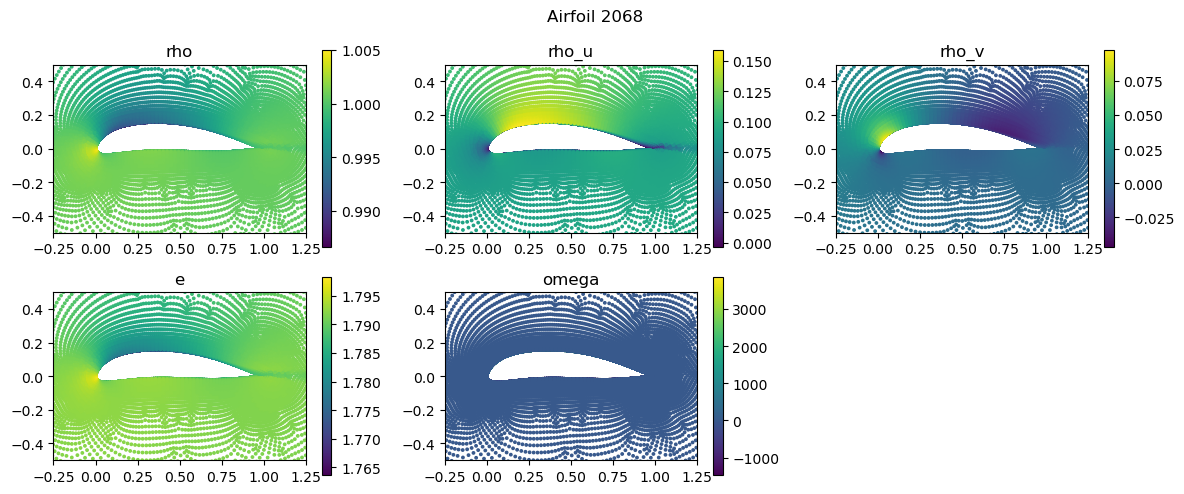

In [ ]:
# Plot flow field data for randomly selected airfoils

val_list = ['rho', 'rho_u', 'rho_v', 'e', 'omega']

with h5py.File(data_path, 'r') as hf:
    idx = np.random.randint(hf['shape']['landmarks'].shape[0])
    
    x = hf['alpha+04']['flow_field']['{:04d}'.format(idx)]['x'][()]
    y = hf['alpha+04']['flow_field']['{:04d}'.format(idx)]['y'][()]
        
    plt.figure(figsize=(12, 5))
    for i, v in enumerate(val_list):
        val = hf['alpha+04']['flow_field']['{:04d}'.format(idx)][v][()]
        
        tf = (x >= -0.25) & (x <= 1.25) & (y >= -0.5) & (y <= 0.5)
        vmin, vmax = np.min(val[tf]), np.max(val[tf])
    
        plt.subplot(2, 3, i+1)
        plt.scatter(x, y, c=val, vmin=vmin, vmax=vmax, s=3)
        plt.xlim(-0.25, 1.25)
        plt.ylim(-0.5, 0.5)
        plt.colorbar()
        plt.title(v)
        plt.gca().set_aspect(1.)

    plt.suptitle('Airfoil {:04d}'.format(idx))
    plt.tight_layout()
    plt.show()